In [5]:
import os
import sys

# 1. CRITICAL: Set framework BEFORE importing segmentation_models
os.environ['SM_FRAMEWORK'] = 'tf.keras'

import tensorflow as tf
import segmentation_models as sm
import matplotlib.pyplot as plt

# 2. Force CPU and clear memory
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
tf.keras.backend.clear_session()

# 3. Import the generator from your file
sys.path.append(os.path.abspath('../src'))
# Ensure you are using the updated utils3.py we discussed
from utils3 import VisionExtractFineTuneGenerator

# 4. Initialize and Verify
train_gen = VisionExtractFineTuneGenerator('../data/processed/train', batch_size=8)
val_gen = VisionExtractFineTuneGenerator('../data/processed/val', batch_size=8)

try:
    X_test, y_test = train_gen[0]
    print(f"✅ Verified Pixel Range: {X_test.min():.2f} to {X_test.max():.2f}")
    if X_test.min() < -100:
        print("🚀 Preprocessing is ACTIVE. ResNet can now see!")
except Exception as e:
    print(f"❌ Error loading batch: {e}")

Segmentation Models: using `tf.keras` framework.

✅ Verified Pixel Range: -123.68 to 151.06
🚀 Preprocessing is ACTIVE. ResNet can now see!


In [2]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install segmentation-models tqdm opencv-python matplotlib

In [2]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np

# Add the root directory to the path so we can import from 'src'
sys.path.append(os.path.abspath('..'))

# Update this line to match your new utils.py
from src.utils import VisionExtractGenerator, dice_loss

In [3]:
from src.model import build_unet

# This line is what actually "builds" the architecture in memory
my_model = build_unet(input_shape=(256, 256, 3))

# This line checks if it was built correctly by showing the layers
my_model.summary()

Model: "VisionExtract_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [5]:
import tensorflow as tf  # Add this line to define 'tf'
import matplotlib.pyplot as plt
import numpy as np

class VisualizeProgress(tf.keras.callbacks.Callback):
    def __init__(self, generator):
        super().__init__()
        self.generator = generator

    def on_epoch_end(self, epoch, logs=None):
        # Only run every 5 epochs
        if (epoch + 1) % 5 == 0:
            # Get a batch of images and masks
            img_batch, mask_batch = self.generator[0]
            
            # Predict using the current state of the U-Net
            pred_mask = self.model.predict(img_batch, verbose=0)
            
            # Plot the results for the first image in the batch
            plt.figure(figsize=(12, 4))
            
            plt.subplot(1, 3, 1)
            plt.imshow(img_batch[0])
            plt.title(f"Epoch {epoch+1}: Original")
            plt.axis('off')
            
            plt.subplot(1, 3, 2)
            plt.imshow(mask_batch[0].squeeze(), cmap='gray')
            plt.title("Ground Truth Mask")
            plt.axis('off')
            
            plt.subplot(1, 3, 3)
            plt.imshow(pred_mask[0].squeeze(), cmap='gray')
            plt.title("Model Prediction")
            plt.axis('off')
            
            plt.show()

In [5]:
from src.utils import VisionExtractGenerator, dice_loss

# 1. Initialize Generators (Pointing to your 'processed' folders)
train_gen = VisionExtractGenerator('../data/processed/train', batch_size=16)
val_gen = VisionExtractGenerator('../data/processed/val', batch_size=16)

# 2. Compile
my_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=2, name='mean_iou')]
)

# 3. Training Callbacks
callbacks = [
    tf.keras.callbacks.ModelCheckpoint('../models/vision_extract_best.keras', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=5, monitor='val_loss'),
    VisualizeProgress(val_gen)
]

# 4. Start Training
history = my_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 4659s 21s/step - accuracy: 0.6819 - loss: 0.4320 - mean_iou: 0.3491 - val_accuracy: 0.7056 - val_loss: 0.9442 - val_mean_iou: 0.3527
Epoch 2/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 4745s 22s/step - accuracy: 0.7217 - loss: 0.3834 - mean_iou: 0.3491 - val_accuracy: 0.7421 - val_loss: 0.6315 - val_mean_iou: 0.3527
Epoch 3/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 4508s 21s/step - accuracy: 0.7361 - loss: 0.3686 - mean_iou: 0.3491 - val_accuracy: 0.7624 - val_loss: 0.3883 - val_mean_iou: 0.3527
Epoch 4/5
  1/218 ━━━━━━━━━━━━━━━━━━━━ 1:07:49 19s/step - accuracy: 0.7362 - loss: 0.3586 - mean_iou: 0.3591

KeyboardInterrupt: 

Epoch 4/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 5221s 24s/step - accuracy: 0.7462 - loss: 0.3575 - mean_iou: 0.3491 - val_accuracy: 0.7377 - val_loss: 0.3611 - val_mean_iou: 0.3527
Epoch 5/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 32s/step - accuracy: 0.7565 - loss: 0.3465 - mean_iou: 0.3486 

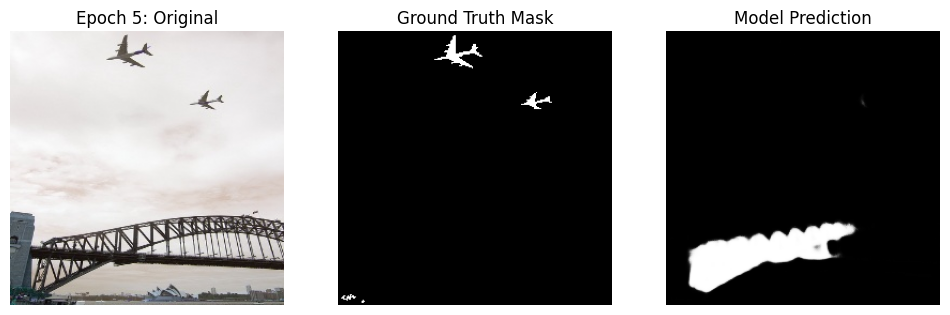

218/218 ━━━━━━━━━━━━━━━━━━━━ 7164s 33s/step - accuracy: 0.7588 - loss: 0.3462 - mean_iou: 0.3491 - val_accuracy: 0.7756 - val_loss: 0.3848 - val_mean_iou: 0.3527


In [4]:
import sys
import os

# 1. Path Fix: Tell Python to look one level up for the 'src' folder
sys.path.append(os.path.abspath('..'))

import tensorflow as tf
from src.utils import VisionExtractGenerator, dice_loss

# 2. Load the Best Model from your models folder
# This picks up all the weights learned during Epochs 1-3
my_model = tf.keras.models.load_model(
    '../models/vision_extract_best.keras',
    custom_objects={'dice_loss': dice_loss}
)

# 3. Initialize Generators with Batch Size 16
# Your fresh RAM after the restart should handle this easily
train_gen = VisionExtractGenerator('../data/processed/train', batch_size=16)
val_gen = VisionExtractGenerator('../data/processed/val', batch_size=16)

# 4. Re-define Callbacks
# We must re-define these because the kernel restart cleared them from memory
callbacks = [
    tf.keras.callbacks.ModelCheckpoint('../models/vision_extract_best.keras', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=3, monitor='val_loss'),
    # Note: Ensure VisualizeProgress is imported or defined in your notebook
    VisualizeProgress(val_gen) 
]

# 5. Resume and finish exactly at Epoch 5
# initial_epoch=3 means 0,1,2 are done. epochs=5 stops after the 5th
history = my_model.fit(
    train_gen,
    validation_data=val_gen,
    initial_epoch=3, 
    epochs=5,
    callbacks=callbacks
)

In [5]:
import sys
import os

# 1. Path Fix: Tell Python to look one level up for the 'src' folder
sys.path.append(os.path.abspath('..'))

import tensorflow as tf
from src.utils import VisionExtractGenerator, dice_loss

# 2. Load the Best Model from your models folder
# This picks up all the weights learned during Epochs 1-3
my_model = tf.keras.models.load_model(
    '../models/vision_extract_best.keras',
    custom_objects={'dice_loss': dice_loss}
)

# 3. Initialize Generators with Batch Size 16
# Your fresh RAM after the restart should handle this easily
train_gen = VisionExtractGenerator('../data/processed/train', batch_size=16)
val_gen = VisionExtractGenerator('../data/processed/val', batch_size=16)

# 4. Re-define Callbacks
# We must re-define these because the kernel restart cleared them from memory
callbacks = [
    tf.keras.callbacks.ModelCheckpoint('../models/vision_extract_best.keras', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=3, monitor='val_loss'),
    # Note: Ensure VisualizeProgress is imported or defined in your notebook
    VisualizeProgress(val_gen) 
]

# 5. Resume and finish exactly at Epoch 5
# initial_epoch=3 means 0,1,2 are done. epochs=5 stops after the 5th
history = my_model.fit(
    train_gen,
    validation_data=val_gen,
    initial_epoch=5, 
    epochs=10,
    callbacks=callbacks
)

Epoch 6/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 5744s 26s/step - accuracy: 0.7571 - loss: 0.3493 - mean_iou: 0.3491 - val_accuracy: 0.7617 - val_loss: 0.3717 - val_mean_iou: 0.3527
Epoch 7/10
 11/218 ━━━━━━━━━━━━━━━━━━━━ 1:11:11 21s/step - accuracy: 0.7719 - loss: 0.3270 - mean_iou: 0.3543

KeyboardInterrupt: 

Epoch 7/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 4464s 20s/step - accuracy: 0.7642 - loss: 0.3396 - mean_iou: 0.3491 - val_accuracy: 0.7804 - val_loss: 0.3576 - val_mean_iou: 0.3527
Epoch 8/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 4482s 21s/step - accuracy: 0.7707 - loss: 0.3337 - mean_iou: 0.3491 - val_accuracy: 0.7770 - val_loss: 0.3559 - val_mean_iou: 0.3527
Epoch 9/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 4482s 21s/step - accuracy: 0.7756 - loss: 0.3271 - mean_iou: 0.3491 - val_accuracy: 0.7735 - val_loss: 0.3356 - val_mean_iou: 0.3527
Epoch 10/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.7832 - loss: 0.3155 - mean_iou: 0.3468 

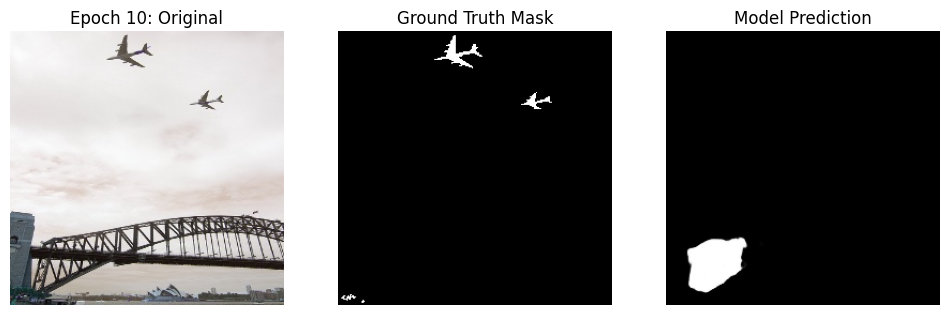

218/218 ━━━━━━━━━━━━━━━━━━━━ 4522s 21s/step - accuracy: 0.7856 - loss: 0.3171 - mean_iou: 0.3491 - val_accuracy: 0.7801 - val_loss: 0.3422 - val_mean_iou: 0.3527


In [3]:
import sys
import os

# 1. Path Fix: Tell Python to look one level up for the 'src' folder
sys.path.append(os.path.abspath('..'))

import tensorflow as tf
from src.utils import VisionExtractGenerator, dice_loss

# 2. Load the Best Model from your models folder
# This picks up all the weights learned during Epochs 1-3
my_model = tf.keras.models.load_model(
    '../models/vision_extract_best.keras',
    custom_objects={'dice_loss': dice_loss}
)

# 3. Initialize Generators with Batch Size 16
# Your fresh RAM after the restart should handle this easily
train_gen = VisionExtractGenerator('../data/processed/train', batch_size=16)
val_gen = VisionExtractGenerator('../data/processed/val', batch_size=16)

# 4. Re-define Callbacks
# We must re-define these because the kernel restart cleared them from memory
callbacks = [
    tf.keras.callbacks.ModelCheckpoint('../models/vision_extract_best.keras', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=3, monitor='val_loss'),
    # Note: Ensure VisualizeProgress is imported or defined in your notebook
    VisualizeProgress(val_gen) 
]

# 5. Resume and finish exactly at Epoch 5
# initial_epoch=3 means 0,1,2 are done. epochs=5 stops after the 5th
history = my_model.fit(
    train_gen,
    validation_data=val_gen,
    initial_epoch=6, 
    epochs=10,
    callbacks=callbacks
)

Epoch 11/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 16442s 76s/step - accuracy: 0.7824 - loss: 0.3194 - mean_iou: 0.3491 - val_accuracy: 0.7218 - val_loss: 0.3596 - val_mean_iou: 0.3527
Epoch 12/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 5373s 25s/step - accuracy: 0.7867 - loss: 0.3147 - mean_iou: 0.3491 - val_accuracy: 0.7206 - val_loss: 0.3574 - val_mean_iou: 0.3527
Epoch 13/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 5757s 26s/step - accuracy: 0.7920 - loss: 0.3093 - mean_iou: 0.3491 - val_accuracy: 0.7742 - val_loss: 0.3393 - val_mean_iou: 0.3527
Epoch 14/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 5956s 27s/step - accuracy: 0.7985 - loss: 0.3013 - mean_iou: 0.3491 - val_accuracy: 0.7934 - val_loss: 0.3329 - val_mean_iou: 0.3527
Epoch 15/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 28s/step - accuracy: 0.8035 - loss: 0.2991 - mean_iou: 0.3514 

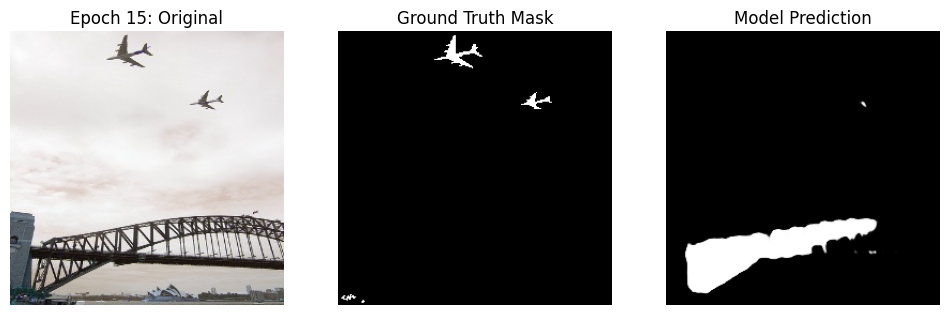

218/218 ━━━━━━━━━━━━━━━━━━━━ 6364s 29s/step - accuracy: 0.8020 - loss: 0.2981 - mean_iou: 0.3491 - val_accuracy: 0.7936 - val_loss: 0.3230 - val_mean_iou: 0.3527


In [2]:
import sys
import os

# 1. Path Fix: Tell Python to look one level up for the 'src' folder
sys.path.append(os.path.abspath('..'))

import tensorflow as tf
from src.utils import VisionExtractGenerator, dice_loss

# 2. Load the Best Model from your models folder
# This picks up all the weights learned during Epochs 1-3
my_model = tf.keras.models.load_model(
    '../models/vision_extract_best.keras',
    custom_objects={'dice_loss': dice_loss}
)

# 3. Initialize Generators with Batch Size 16
# Your fresh RAM after the restart should handle this easily
train_gen = VisionExtractGenerator('../data/processed/train', batch_size=16)
val_gen = VisionExtractGenerator('../data/processed/val', batch_size=16)

# 4. Re-define Callbacks
# We must re-define these because the kernel restart cleared them from memory
callbacks = [
    tf.keras.callbacks.ModelCheckpoint('../models/vision_extract_best.keras', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=3, monitor='val_loss'),
    # Note: Ensure VisualizeProgress is imported or defined in your notebook
    VisualizeProgress(val_gen) 
]

# 5. Resume and finish exactly at Epoch 5
# initial_epoch=3 means 0,1,2 are done. epochs=5 stops after the 5th
history = my_model.fit(
    train_gen,
    validation_data=val_gen,
    initial_epoch=10, 
    epochs=15,
    callbacks=callbacks
)

Starting fine-tuning with thresholded IoU monitoring...
Epoch 1/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 7350s 34s/step - accuracy: 0.7605 - bg_iou: 0.6895 - loss: 0.3501 - mean_iou: 0.5870 - subject_iou: 0.4846 - val_accuracy: 0.7923 - val_bg_iou: 0.7394 - val_loss: 0.3465 - val_mean_iou: 0.6153 - val_subject_iou: 0.4912
Epoch 2/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 8689s 40s/step - accuracy: 0.7655 - bg_iou: 0.6948 - loss: 0.3431 - mean_iou: 0.5938 - subject_iou: 0.4928 - val_accuracy: 0.7847 - val_bg_iou: 0.7229 - val_loss: 0.3335 - val_mean_iou: 0.6138 - val_subject_iou: 0.5048
Epoch 3/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 8078s 37s/step - accuracy: 0.7700 - bg_iou: 0.7005 - loss: 0.3382 - mean_iou: 0.5993 - subject_iou: 0.4982 - val_accuracy: 0.7866 - val_bg_iou: 0.7262 - val_loss: 0.3342 - val_mean_iou: 0.6153 - val_subject_iou: 0.5044
Epoch 4/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 8213s 37s/step - accuracy: 0.7733 - bg_iou: 0.7047 - loss: 0.3346 - mean_iou: 0.6034 - subject_iou: 0.5022 - val_accuracy: 0.7802 -

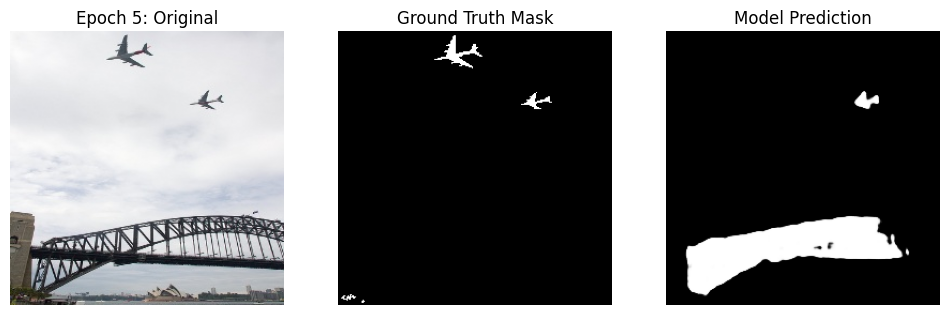

218/218 ━━━━━━━━━━━━━━━━━━━━ 7999s 37s/step - accuracy: 0.7752 - bg_iou: 0.7066 - loss: 0.3317 - mean_iou: 0.6061 - subject_iou: 0.5055 - val_accuracy: 0.7961 - val_bg_iou: 0.7415 - val_loss: 0.3340 - val_mean_iou: 0.6235 - val_subject_iou: 0.5054


In [8]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import tensorflow as tf
from src.utils1 import VisionExtractFineTuneGenerator, dice_loss

# 1. Initialize Generators
train_gen = VisionExtractFineTuneGenerator('../data/processed/train', batch_size=16)
val_gen = VisionExtractFineTuneGenerator('../data/processed/val', batch_size=16)

# 2. Load the model
model_path = '../models/vision_extract_best.keras'
my_model = tf.keras.models.load_model(model_path, custom_objects={'dice_loss': dice_loss})

# 3. Compile with Comprehensive IoU Metrics
my_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss=dice_loss,
    metrics=[
        'accuracy',
        # Background IoU (Class 0)
        tf.keras.metrics.BinaryIoU(target_class_ids=[0], threshold=0.3, name='bg_iou'),
        # Subject IoU (Class 1)
        tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.3, name='subject_iou'),
        # Mean IoU using a threshold to ensure it doesn't get stuck at 0.35
        tf.keras.metrics.BinaryIoU(target_class_ids=[0, 1], threshold=0.3, name='mean_iou')
    ]
)

# 4. Callbacks
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        '../models/vision_extract_fine_tuning.keras', 
        save_best_only=True, 
        monitor='val_subject_iou', 
        mode='max'
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=3, 
        monitor='val_subject_iou', 
        mode='max',
        restore_best_weights=True
    ),
    VisualizeProgress(val_gen)
]

# 5. Start Fine-Tuning
print("Starting fine-tuning with thresholded IoU monitoring...")
history = my_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5, 
    callbacks=callbacks
)

In [10]:
import sys
import os
import tensorflow as tf

# 1. Connect src folder to Notebook
sys.path.append(os.path.abspath('..')) 

from src.utils1 import VisionExtractFineTuneGenerator, dice_loss
from src.utils2 import VisionExtractAdvancedGenerator
from src.model1 import build_unet_v2

# 2. Initialize Generators
# Training uses the new Advanced Generator for Week 5
train_gen_v2 = VisionExtractAdvancedGenerator('../data/processed/train', batch_size=16)

# FIX: Define val_gen explicitly so it is no longer a NameError
val_gen = VisionExtractFineTuneGenerator('../data/processed/val', batch_size=16)

# 3. Build the Week 5 Architecture (Attention + Dropout) [cite: 69]
model_v2 = build_unet_v2((256, 256, 3))

# 4. Manual Weight Transfer to bypass Keras 3 restriction
latest_weights_path = '../models/vision_extract_fine_tuning.keras'

if os.path.exists(latest_weights_path):
    #print("Loading previous fine-tuned model for weight transfer...")
    old_model = tf.keras.models.load_model(latest_weights_path, custom_objects={'dice_loss': dice_loss})
    
    for layer in model_v2.layers:
        try:
            old_layer = old_model.get_layer(name=layer.name)
            layer.set_weights(old_layer.get_weights())
        except (ValueError, KeyError):
            # Skips the new Attention Gates and Dropout layers
            continue
    #print("Weight transfer complete.")

# 5. Compile with complete Metric suite [cite: 43, 94]
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6), 
    loss=dice_loss,
    metrics=[
        tf.keras.metrics.BinaryIoU(target_class_ids=[0], threshold=0.5, name='bg_iou'),
        tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5, name='subject_iou'),
        tf.keras.metrics.BinaryIoU(target_class_ids=[0, 1], threshold=0.5, name='mean_iou')
    ]
)

# 6. Callbacks for Milestone 3 [cite: 67]
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        '../models/vision_extract_adv.keras',
        save_best_only=True,
        monitor='val_subject_iou',
        mode='max'
    ),
    tf.keras.callbacks.EarlyStopping(patience=3, monitor='val_subject_iou', mode='max')
]

# 7. Start Training [cite: 60, 62]
print("Starting Week 5 Training with Attention Gates and Advanced Augmentation...")
history_v2 = model_v2.fit(
    train_gen_v2,
    validation_data=val_gen, 
    epochs=5,
    callbacks=callbacks
)

Starting Week 5 Training with Attention Gates and Advanced Augmentation...
Epoch 1/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 7232s 33s/step - bg_iou: 0.2712 - loss: 0.5777 - mean_iou: 0.2845 - subject_iou: 0.2979 - val_bg_iou: 0.2430 - val_loss: 0.6229 - val_mean_iou: 0.2601 - val_subject_iou: 0.2772
Epoch 2/5
  2/218 ━━━━━━━━━━━━━━━━━━━━ 1:18:36 22s/step - bg_iou: 0.3104 - loss: 0.5305 - mean_iou: 0.3275 - subject_iou: 0.3446

KeyboardInterrupt: 

In [4]:
import tensorflow as tf
import os
import sys

# Connect to your src folder
sys.path.append(os.path.abspath('..')) 
from src.utils1 import VisionExtractFineTuneGenerator, dice_loss

# 1. Re-initialize the Validation Generator
val_gen = VisionExtractFineTuneGenerator('../data/processed/val', batch_size=16)

# 2. Load the best model saved during Week 5 training
model_path = '../models/vision_extract_adv.keras'

if os.path.exists(model_path):
    # We use custom_objects because 'dice_loss' isn't a standard Keras function
    model_v2 = tf.keras.models.load_model(model_path, custom_objects={'dice_loss': dice_loss})
    print("Best Week 5 model loaded successfully!")
else:
    print("Model file not found. Check your path in the 'models' folder.")

Best Week 5 model loaded successfully!


In [7]:
import cv2
import numpy as np

def apply_post_processing(binary_mask):
    """
    Cleans up the binary mask using Morphological Operations.
    - Opening: Removes small white noise (speckles) in the background.
    - Closing: Fills small black holes inside the subject.
    """
    # Ensure mask is uint8 for OpenCV
    mask_uint8 = (binary_mask * 255).astype(np.uint8)
    
    # Define a 5x5 kernel
    kernel = np.ones((5, 5), np.uint8)
    
    # 1. Remove noise (Opening)
    cleaned = cv2.morphologyEx(mask_uint8, cv2.MORPH_OPEN, kernel)
    
    # 2. Fill holes (Closing)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)
    
    return cleaned / 255.0

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_with_cleanup(model, generator):
    # Get the first batch from the validation generator
    x_batch, y_batch = generator[0]
    # Predict using the Week 5 model [cite: 30]
    raw_preds = model.predict(x_batch)

    # Set up a 4-column figure for a complete comparison
    plt.figure(figsize=(20, 5))
    
    # 1. Original Image [cite: 25]
    plt.subplot(1, 4, 1)
    plt.imshow(x_batch[0])
    plt.title("Original Image")
    plt.axis('off')
    
    # 2. Ground Truth Mask [cite: 25]
    plt.subplot(1, 4, 2)
    plt.imshow(y_batch[0].squeeze(), cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis('off')
    
    # 3. Raw Prediction (Week 5 Model with 0.5 Threshold) [cite: 30]
    plt.subplot(1, 4, 3)
    raw_mask = (raw_preds[0] > 0.7).astype(np.float32)
    plt.imshow(raw_mask.squeeze(), cmap='gray')
    plt.title("Raw Prediction (0.7 Thresh)")
    plt.axis('off')
    
    # 4. Post-Processed (Cleaned) Mask 
    plt.subplot(1, 4, 4)
    # Ensure apply_post_processing is defined in your notebook
    clean_mask = apply_post_processing(raw_mask)
    plt.imshow(clean_mask.squeeze(), cmap='gray')
    plt.title("Post-Processed Mask")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [20]:
# 1. Update the initial epoch to 1 so the logs show correctly (Epoch 2/3)
# 2. Set epochs=3 to finish the remaining two rounds
print("Continuing Week 5 Training: Epochs 2 and 3...")

history_v2_continued = model_v2.fit(
    train_gen_v2,
    validation_data=val_gen,
    initial_epoch=1, # Tells Keras we already finished Epoch 1
    epochs=3,        # Trains until the end of Epoch 3
    callbacks=callbacks
)

Continuing Week 5 Training: Epochs 2 and 3...
Epoch 2/3
218/218 ━━━━━━━━━━━━━━━━━━━━ 9477s 44s/step - bg_iou: 0.3607 - loss: 0.5356 - mean_iou: 0.3482 - subject_iou: 0.3356 - val_bg_iou: 0.6120 - val_loss: 0.5827 - val_mean_iou: 0.4666 - val_subject_iou: 0.3212
Epoch 3/3
218/218 ━━━━━━━━━━━━━━━━━━━━ 7696s 35s/step - bg_iou: 0.4459 - loss: 0.4963 - mean_iou: 0.4096 - subject_iou: 0.3733 - val_bg_iou: 0.5955 - val_loss: 0.5000 - val_mean_iou: 0.4948 - val_subject_iou: 0.3941


In [23]:
print("Continuing Week 5 Training: Epochs 4 and 5...")

history_v2_continued = model_v2.fit(
    train_gen_v2,
    validation_data=val_gen,
    initial_epoch=3, # Tells Keras we already finished Epoch 3
    epochs=5,        # Trains until the end of Epoch 5
    callbacks=callbacks
)

Continuing Week 5 Training: Epochs 4 and 5...
Epoch 4/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 6171s 28s/step - bg_iou: 0.5011 - loss: 0.4691 - mean_iou: 0.4497 - subject_iou: 0.3982 - val_bg_iou: 0.6019 - val_loss: 0.4643 - val_mean_iou: 0.5089 - val_subject_iou: 0.4159
Epoch 5/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 7178s 33s/step - bg_iou: 0.5384 - loss: 0.4514 - mean_iou: 0.4759 - subject_iou: 0.4134 - val_bg_iou: 0.6266 - val_loss: 0.4457 - val_mean_iou: 0.5277 - val_subject_iou: 0.4288


In [ ]:
print("Continuing Week 5 Training: Epochs 6 and 10...")

history_v2_continued = model_v2.fit(
    train_gen_v2,
    validation_data=val_gen,
    initial_epoch=5, # Tells Keras we already finished Epoch 5
    epochs=10,        # Trains until the end of Epoch 10.
    callbacks=callbacks
)

Continuing Week 5 Training: Epochs 6 and 10...
Epoch 6/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 6887s 32s/step - bg_iou: 0.5670 - loss: 0.4365 - mean_iou: 0.4966 - subject_iou: 0.4262 - val_bg_iou: 0.6435 - val_loss: 0.4354 - val_mean_iou: 0.5390 - val_subject_iou: 0.4344
Epoch 7/10
170/218 ━━━━━━━━━━━━━━━━━━━━ 23:38 30s/step - bg_iou: 0.5744 - loss: 0.4275 - mean_iou: 0.5027 - subject_iou: 0.4310

In [7]:
import tensorflow as tf
import os
import sys

# Connect to your src folder
sys.path.append(os.path.abspath('..')) 
from src.utils1 import VisionExtractFineTuneGenerator, dice_loss

# 1. Re-initialize the Validation Generator
val_gen = VisionExtractFineTuneGenerator('../data/processed/val', batch_size=16)

# 2. Load the best model saved during Week 5 training
model_path = '../models/vision_extract_adv.keras'

if os.path.exists(model_path):
    # We use custom_objects because 'dice_loss' isn't a standard Keras function
    model_v2 = tf.keras.models.load_model(model_path, custom_objects={'dice_loss': dice_loss})
    print("Best Week 5 model loaded successfully!")
else:
    print("Model file not found. Check your path in the 'models' folder.")

Best Week 5 model loaded successfully!


In [10]:
import sys
import os
import tensorflow as tf

# 1. Path Setup
sys.path.append(os.path.abspath('..')) 
from src.utils1 import VisionExtractFineTuneGenerator, dice_loss
from src.utils2 import VisionExtractAdvancedGenerator

# 2. Re-define Generators
train_gen_v2 = VisionExtractAdvancedGenerator('../data/processed/train', batch_size=16)
val_gen = VisionExtractFineTuneGenerator('../data/processed/val', batch_size=16)

# 3. Load the model from the last successful checkpoint
# This ensures you start with the 43% IoU weights, not random ones
model_v2 = tf.keras.models.load_model('../models/vision_extract_adv.keras', 
                                     custom_objects={'dice_loss': dice_loss})

print("Environment restored. Ready to resume from Epoch 7.")

Environment restored. Ready to resume from Epoch 7.


In [12]:
import tensorflow as tf

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        '../models/vision_extract_adv.keras',
        save_best_only=True,
        monitor='val_subject_iou',
        mode='max'
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=3, 
        monitor='val_subject_iou', 
        mode='max'
    )
]

print("Callbacks defined. You are ready to train!")

Callbacks defined. You are ready to train!


In [13]:
print("Continuing Week 5 Training: Epochs 7 and 10...")

history_v2_continued = model_v2.fit(
    train_gen_v2,
    validation_data=val_gen,
    initial_epoch=6, # Tells Keras we already finished Epoch 6
    epochs=10,        # Trains until the end of Epoch 10.
    callbacks=callbacks
)

Continuing Week 5 Training: Epochs 7 and 10...
Epoch 7/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 7673s 35s/step - bg_iou: 0.5780 - loss: 0.4245 - mean_iou: 0.5059 - subject_iou: 0.4339 - val_bg_iou: 0.6608 - val_loss: 0.4322 - val_mean_iou: 0.5469 - val_subject_iou: 0.4329
Epoch 8/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 7571s 35s/step - bg_iou: 0.5873 - loss: 0.4158 - mean_iou: 0.5132 - subject_iou: 0.4391 - val_bg_iou: 0.6517 - val_loss: 0.4157 - val_mean_iou: 0.5476 - val_subject_iou: 0.4435
Epoch 9/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 6949s 32s/step - bg_iou: 0.5956 - loss: 0.4090 - mean_iou: 0.5193 - subject_iou: 0.4431 - val_bg_iou: 0.6587 - val_loss: 0.4124 - val_mean_iou: 0.5509 - val_subject_iou: 0.4432
Epoch 10/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 7318s 34s/step - bg_iou: 0.6034 - loss: 0.4039 - mean_iou: 0.5248 - subject_iou: 0.4461 - val_bg_iou: 0.6705 - val_loss: 0.4105 - val_mean_iou: 0.5572 - val_subject_iou: 0.4439


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


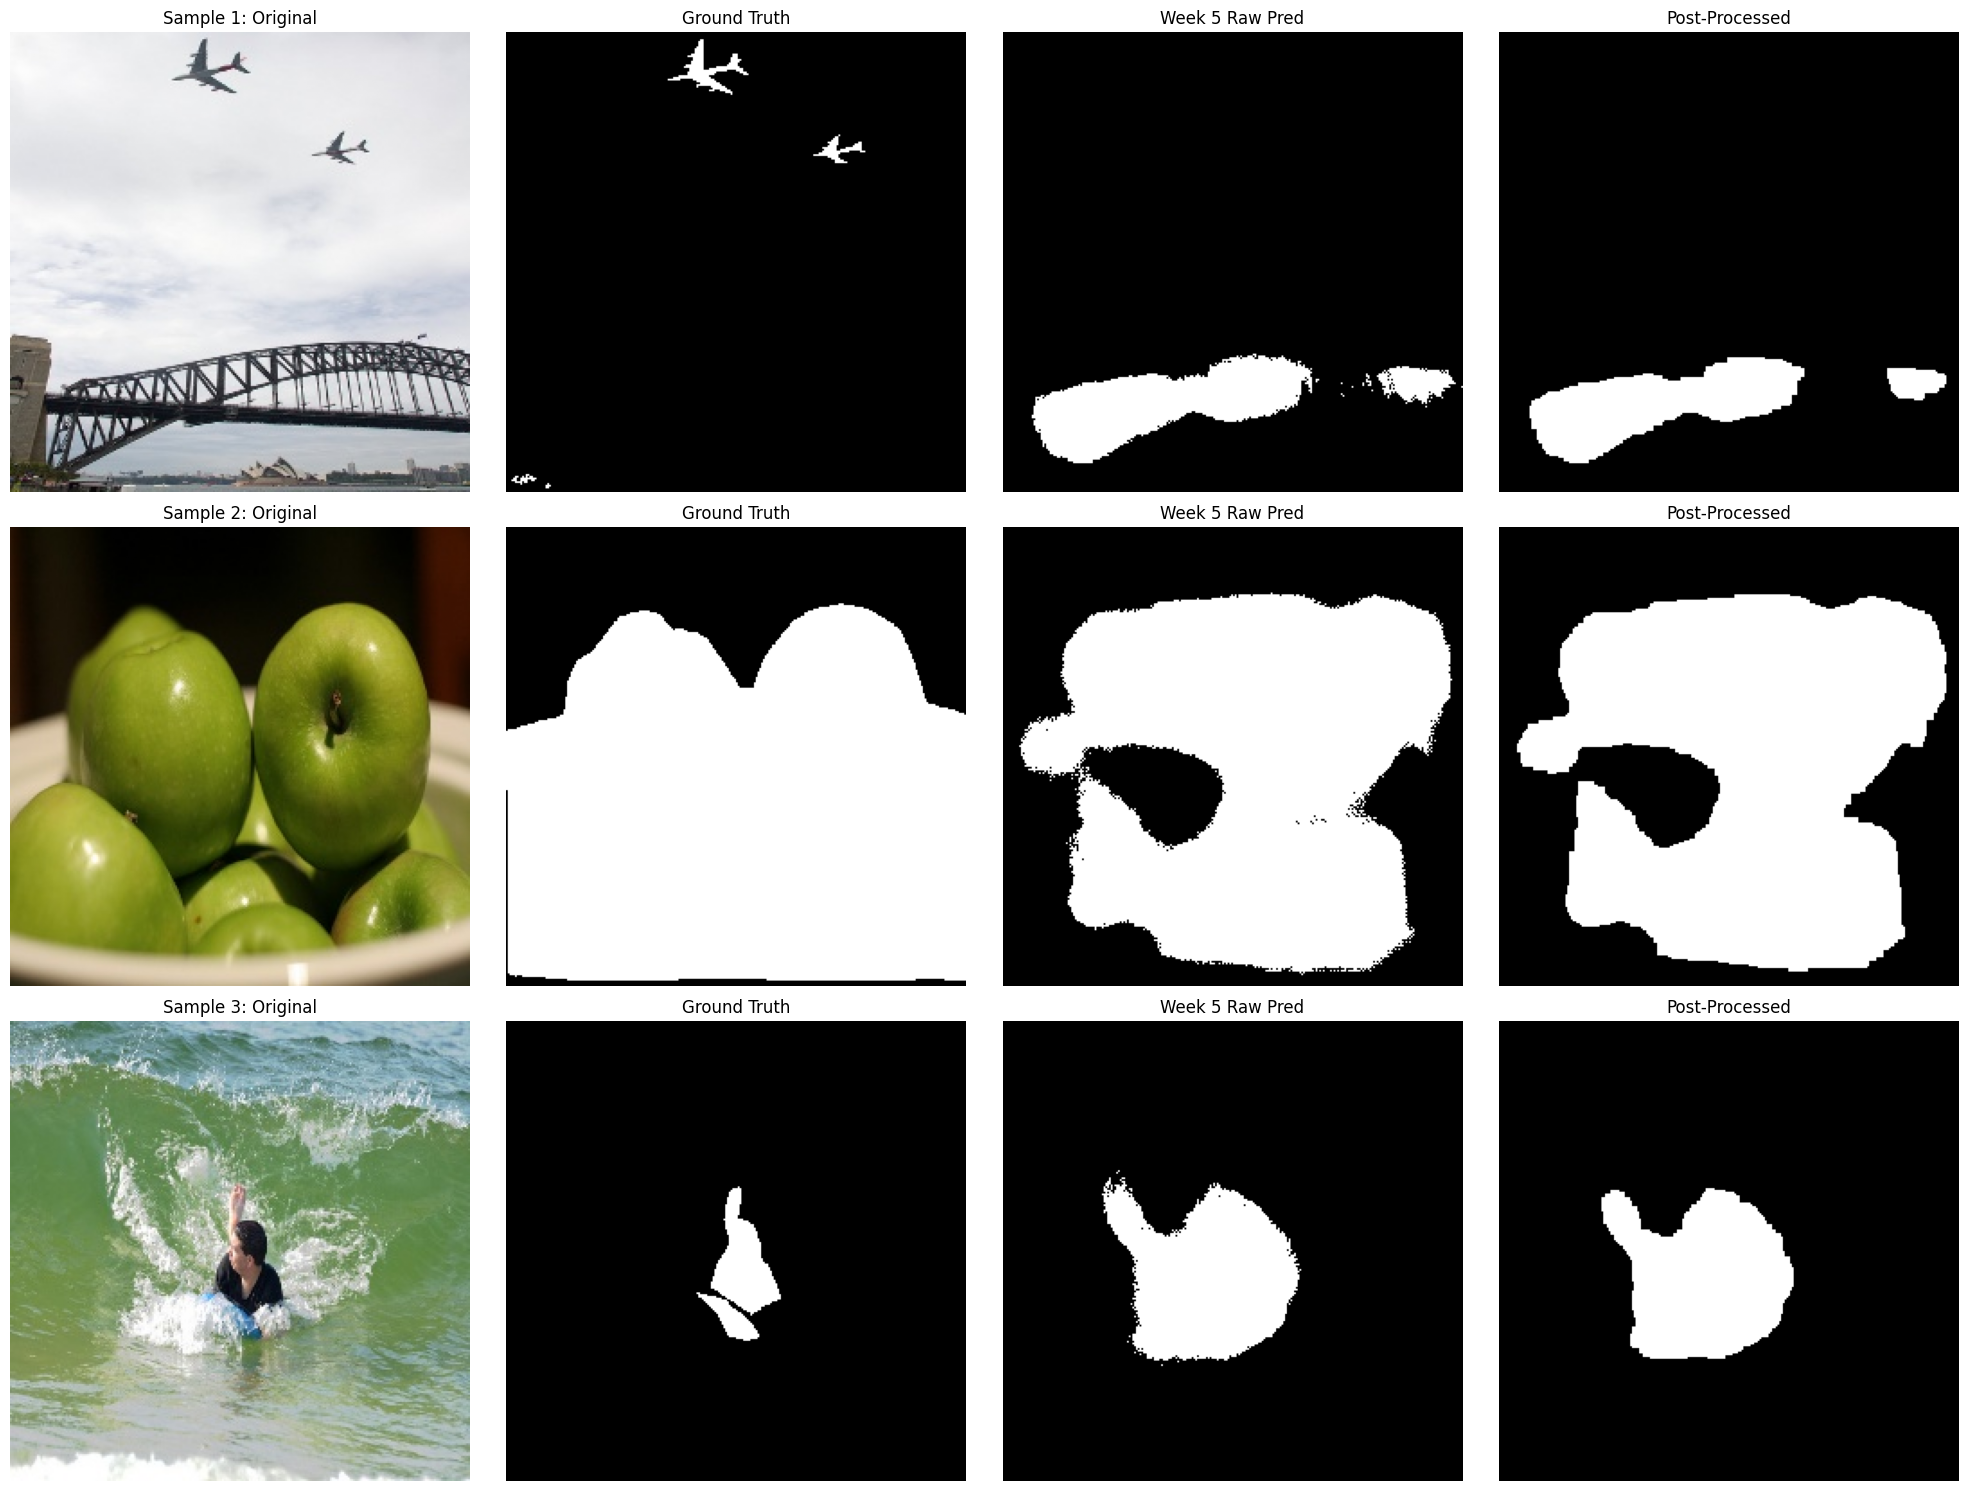

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

def visualize_multi_samples(model, generator, num_samples=3):
    # Get a batch of data
    x_batch, y_batch = generator[0]
    raw_preds = model.predict(x_batch)

    # Create a grid: Rows = num_samples, Columns = 4
    plt.figure(figsize=(20, 5 * num_samples))
    
    for i in range(num_samples):
        # 1. Original Image
        plt.subplot(num_samples, 4, i*4 + 1)
        plt.imshow(x_batch[i])
        plt.title(f"Sample {i+1}: Original")
        plt.axis('off')
        
        # 2. Ground Truth Mask
        plt.subplot(num_samples, 4, i*4 + 2)
        plt.imshow(y_batch[i].squeeze(), cmap='gray')
        plt.title("Ground Truth")
        plt.axis('off')
        
        # 3. Raw Prediction (0.5 Threshold)
        plt.subplot(num_samples, 4, i*4 + 3)
        raw_mask = (raw_preds[i] > 0.5).astype(np.float32)
        plt.imshow(raw_mask.squeeze(), cmap='gray')
        plt.title("Week 5 Raw Pred")
        plt.axis('off')
        
        # 4. Post-Processed (Cleaned) Mask
        plt.subplot(num_samples, 4, i*4 + 4)
        # Ensure your apply_post_processing function is defined!
        clean_mask = apply_post_processing(raw_mask)
        plt.imshow(clean_mask.squeeze(), cmap='gray')
        plt.title("Post-Processed")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Run it!
visualize_multi_samples(model_v2, val_gen, num_samples=3)

In [16]:
print("Continuing Week 5 Training: Epochs 10 and 15...")

history_v2_continued = model_v2.fit(
    train_gen_v2,
    validation_data=val_gen,
    initial_epoch=10, # Tells Keras we already finished Epoch 10
    epochs=15,        # Trains until the end of Epoch 15.
    callbacks=callbacks
)

Continuing Week 5 Training: Epochs 10 and 15...
Epoch 11/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 7159s 33s/step - bg_iou: 0.6095 - loss: 0.4001 - mean_iou: 0.5289 - subject_iou: 0.4484 - val_bg_iou: 0.6635 - val_loss: 0.4038 - val_mean_iou: 0.5559 - val_subject_iou: 0.4482
Epoch 12/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 7438s 34s/step - bg_iou: 0.6117 - loss: 0.3961 - mean_iou: 0.5311 - subject_iou: 0.4505 - val_bg_iou: 0.6491 - val_loss: 0.3973 - val_mean_iou: 0.5503 - val_subject_iou: 0.4515
Epoch 13/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 7781s 36s/step - bg_iou: 0.6193 - loss: 0.3926 - mean_iou: 0.5362 - subject_iou: 0.4532 - val_bg_iou: 0.6709 - val_loss: 0.3999 - val_mean_iou: 0.5599 - val_subject_iou: 0.4489
Epoch 14/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 7441s 34s/step - bg_iou: 0.6209 - loss: 0.3900 - mean_iou: 0.5379 - subject_iou: 0.4548 - val_bg_iou: 0.6869 - val_loss: 0.4098 - val_mean_iou: 0.5621 - val_subject_iou: 0.4372
Epoch 15/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 8219s 38s/step - bg_iou: 0.6270 - loss:

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


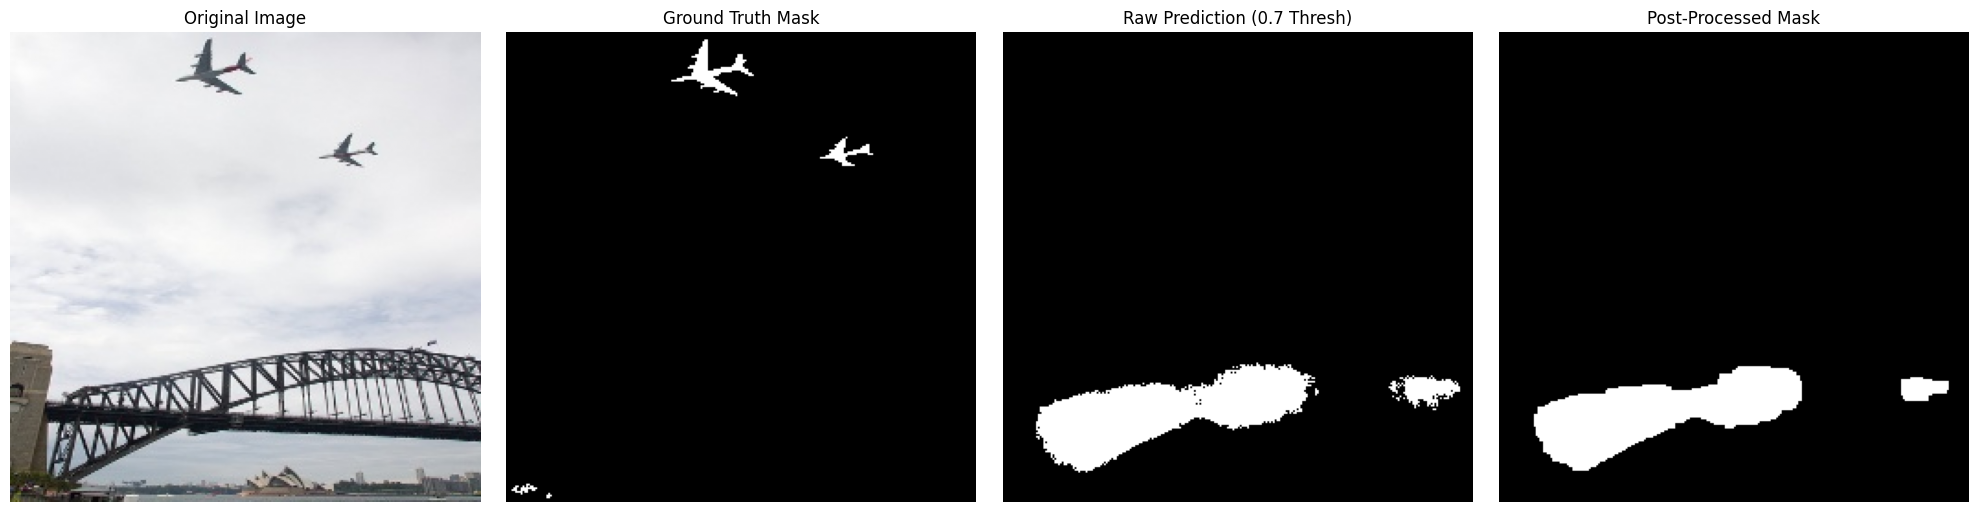

In [10]:
visualize_with_cleanup(model_v2, val_gen)

In [1]:
import tensorflow as tf
import os
import sys

# Connect to your src folder
sys.path.append(os.path.abspath('..')) 
from src.utils1 import VisionExtractFineTuneGenerator, dice_loss

# 1. Re-initialize the Validation Generator
val_gen = VisionExtractFineTuneGenerator('../data/processed/val', batch_size=16)

# 2. Load the best model saved during Week 5 training
model_path = '../models/vision_extract_fine_tuning.keras'

if os.path.exists(model_path):
    # We use custom_objects because 'dice_loss' isn't a standard Keras function
    model_final = tf.keras.models.load_model(model_path, custom_objects={'dice_loss': dice_loss})
    print("Best Week 4 model loaded successfully!")
else:
    print("Model file not found. Check your path in the 'models' folder.")

Best Week 4 model loaded successfully!


In [2]:
from tqdm.notebook import tqdm
import numpy as np
import cv2

def apply_week5_cleanup_FINAL(binary_mask):
    mask_uint8 = (binary_mask * 255).astype(np.uint8)
    big_kernel = np.ones((7, 7), np.uint8)
    closed = cv2.morphologyEx(mask_uint8, cv2.MORPH_CLOSE, big_kernel)
    small_kernel = np.ones((3, 3), np.uint8)
    opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, small_kernel)
    contours, _ = cv2.findContours(opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    final_mask = np.zeros_like(opened)
    for cnt in contours:
        if cv2.contourArea(cnt) > 100: 
            cv2.drawContours(final_mask, [cnt], -1, 1, -1)
    return final_mask 

def evaluate_comprehensive_metrics(model, generator):
    sub_ious = []
    bg_ious = []
    
    # 1. Get the Model Loss first using Keras built-in evaluate
    print("Calculating Model Loss...")
    results = model.evaluate(generator, verbose=0)
    # result[0] is typically loss, but check your model.metrics_names if unsure
    final_loss = results[0] 

    print("Running Final Per-Pixel Evaluation...")
    for i in tqdm(range(len(generator))):
        x_batch, y_batch = generator[i]
        preds = model.predict(x_batch, verbose=0)
        
        for j in range(len(preds)):
            # Thresholding and Cleanup
            raw_mask = (preds[j] > 0.5).astype(np.float32)
            final_sub_mask = apply_week5_cleanup_FINAL(raw_mask)
            final_bg_mask = 1 - final_sub_mask # Inverse for background
            
            # Ground Truth
            gt_sub = y_batch[j].squeeze().astype(np.uint8)
            gt_bg = 1 - gt_sub
            
            # Subject IoU Calculation
            intersection_sub = np.logical_and(gt_sub == 1, final_sub_mask == 1).sum()
            union_sub = np.logical_or(gt_sub == 1, final_sub_mask == 1).sum()
            sub_ious.append(intersection_sub / (union_sub + 1e-7))

            # Background IoU Calculation
            intersection_bg = np.logical_and(gt_bg == 1, final_bg_mask == 1).sum()
            union_bg = np.logical_or(gt_bg == 1, final_bg_mask == 1).sum()
            bg_ious.append(intersection_bg / (union_bg + 1e-7))
            
    mean_sub_iou = np.mean(sub_ious)
    mean_bg_iou = np.mean(bg_ious)
    overall_mean_iou = (mean_sub_iou + mean_bg_iou) / 2

    return final_loss, mean_bg_iou, mean_sub_iou, overall_mean_iou

# --- EXECUTION ---
loss, bg_iou, sub_iou, mean_iou = evaluate_comprehensive_metrics(model_final, val_gen)

print("\n" + "="*30)
print("       FINAL MILESTONE 3 REPORT")
print("="*30)
print(f"📉 Validation Loss: {loss:.4f}")
print(f"🌳 Background IoU:  {bg_iou:.4f}")
print(f"🚀 Subject IoU:     {sub_iou:.4f}")
print(f"📊 Mean IoU (mIoU): {mean_iou:.4f}")
print("="*30)

Calculating Model Loss...
Running Final Per-Pixel Evaluation...


  0%|          | 0/46 [00:00<?, ?it/s]


       FINAL MILESTONE 3 REPORT
📉 Validation Loss: 0.3301
🌳 Background IoU:  0.6732
🚀 Subject IoU:     0.4683
📊 Mean IoU (mIoU): 0.5707


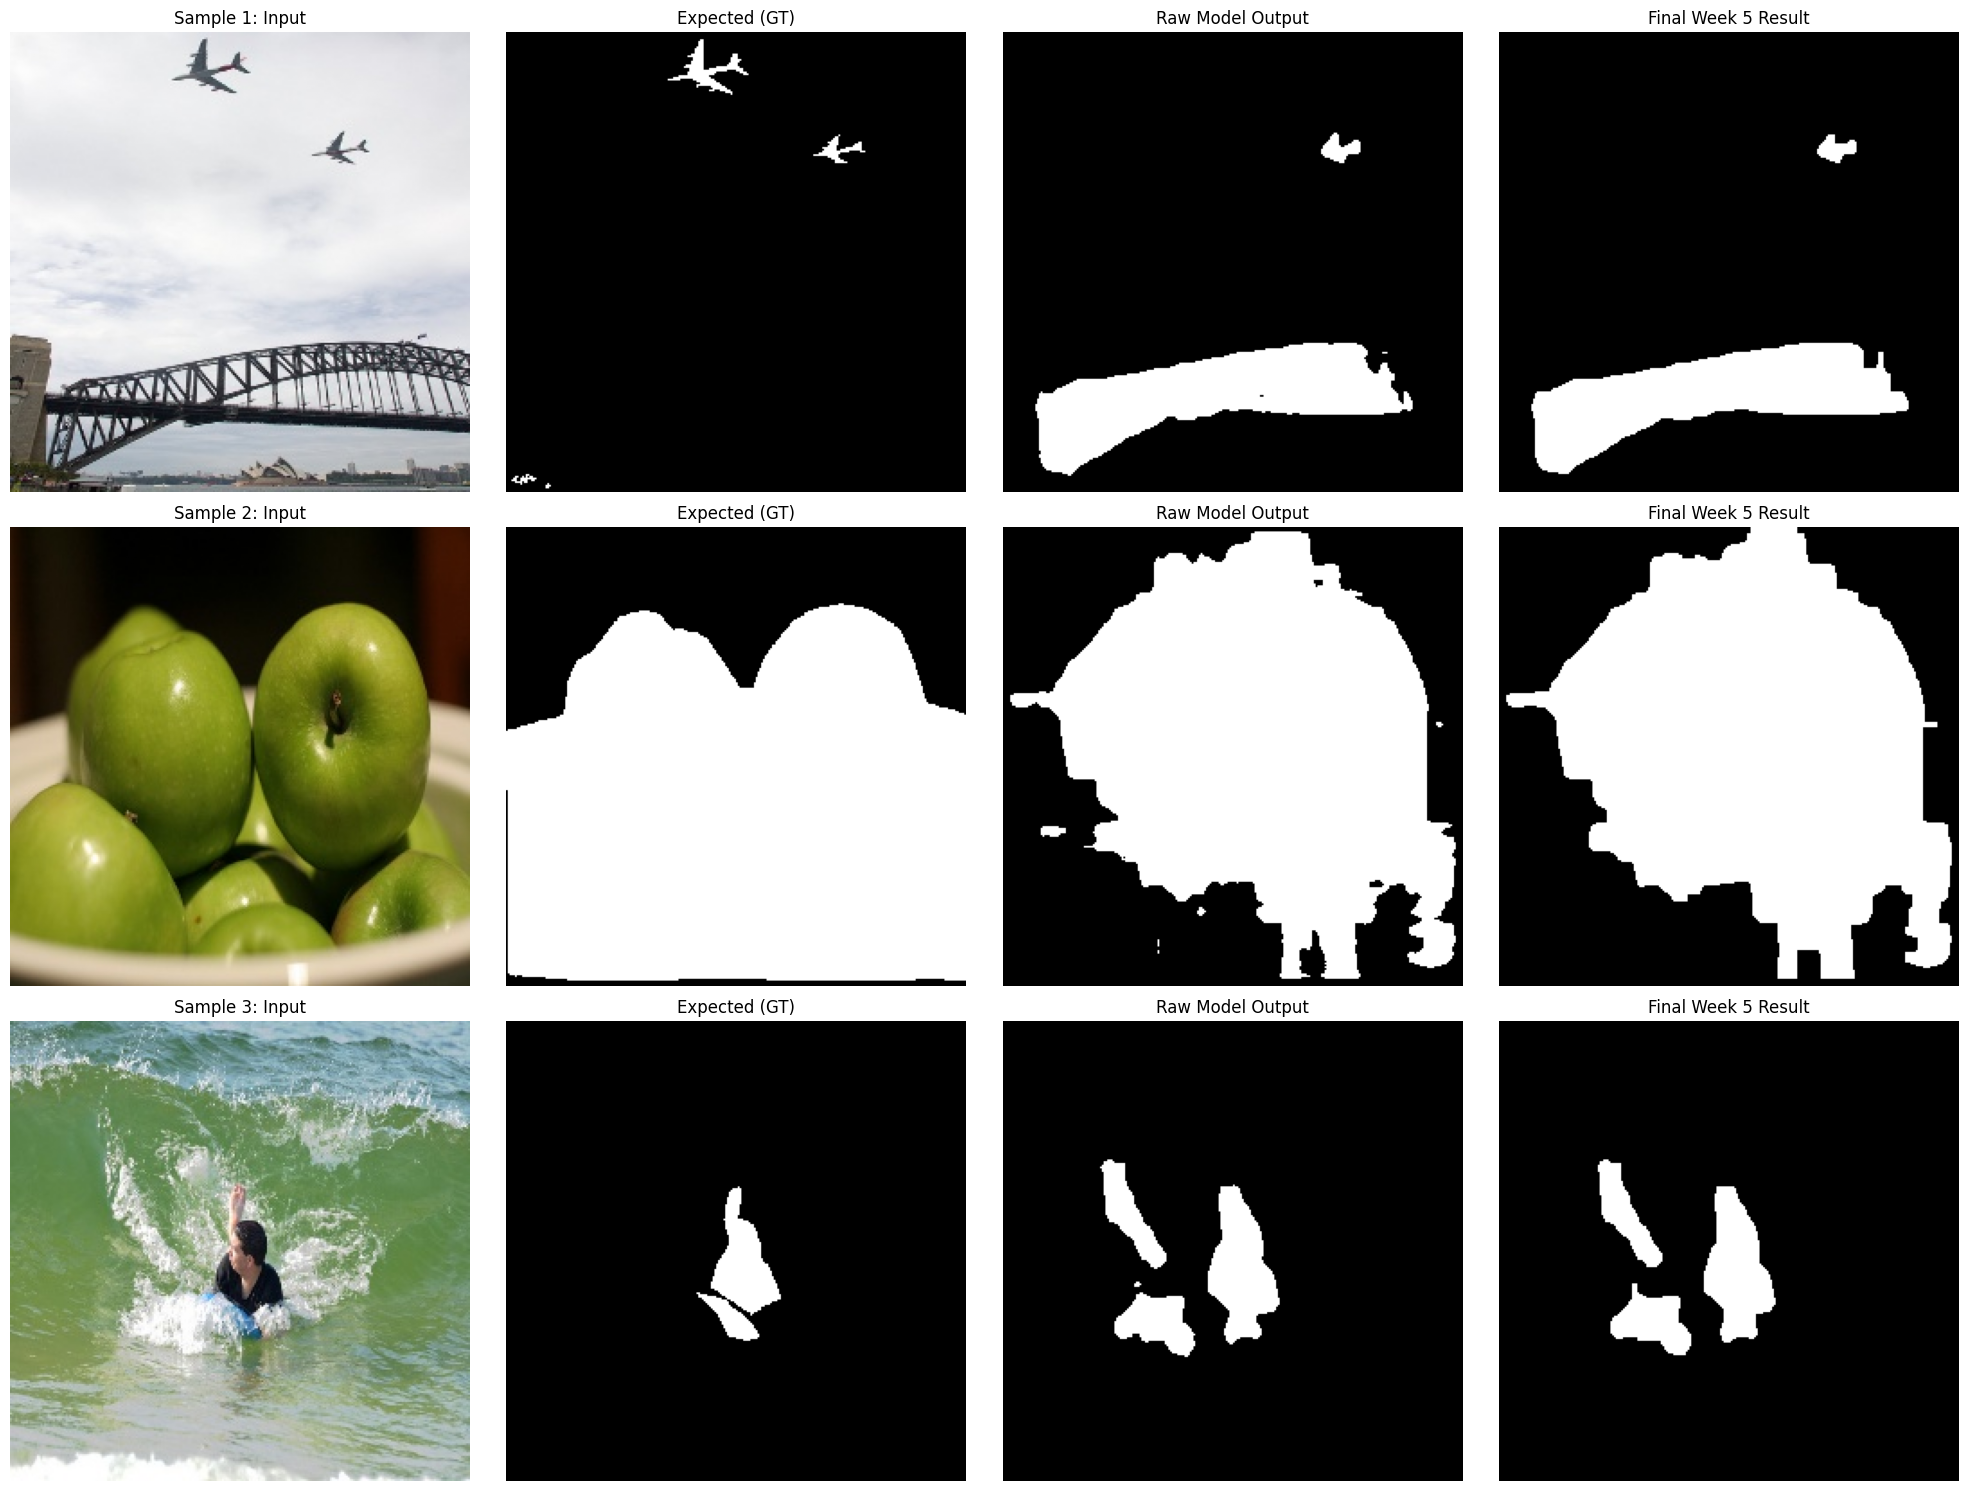

✅ Visualization complete. Report image saved as 'milestone3_results.png'


In [4]:
import matplotlib.pyplot as plt
import numpy as np

def generate_final_report_visuals(model, generator, num_samples=3):
    # 1. Get the first batch of data from the generator
    x_batch, y_batch = generator[0]
    
    # 2. Get raw predictions from the model
    raw_preds = model.predict(x_batch, verbose=0)

    plt.figure(figsize=(20, 5 * num_samples))

    for i in range(min(num_samples, len(x_batch))):
        # --- Column 1: Original Image ---
        plt.subplot(num_samples, 4, i*4 + 1)
        plt.imshow(x_batch[i])
        plt.title(f"Sample {i+1}: Input")
        plt.axis('off')

        # --- Column 2: Ground Truth (What it SHOULD look like) ---
        plt.subplot(num_samples, 4, i*4 + 2)
        plt.imshow(y_batch[i].squeeze(), cmap='gray')
        plt.title("Expected (GT)")
        plt.axis('off')

        # --- Column 3: Raw Model Output (Before cleanup) ---
        plt.subplot(num_samples, 4, i*4 + 3)
        # We apply the same 0.5 threshold used in your evaluation code
        raw_mask = (raw_preds[i] > 0.5).astype(np.float32)
        plt.imshow(raw_mask.squeeze(), cmap='gray')
        plt.title("Raw Model Output")
        plt.axis('off')

        # --- Column 4: Final Result (After Week 5 Cleanup) ---
        plt.subplot(num_samples, 4, i*4 + 4)
        # Calling your defined apply_week5_cleanup_FINAL function
        final_mask = apply_week5_cleanup_FINAL(raw_mask)
        plt.imshow(final_mask.squeeze(), cmap='gray')
        plt.title("Final Week 5 Result")
        plt.axis('off')

    plt.tight_layout()
    # Save the result for your report
    plt.savefig('milestone3_results.png') 
    plt.show()
    print("✅ Visualization complete. Report image saved as 'milestone3_results.png'")

# Execute the visualizer with your best model and validation data
generate_final_report_visuals(model_final, val_gen)

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def vision_extract_inference(image_path, model, output_path="isolated_subject.png"):
    # 1. Load and Preprocess
    # Adjust size (e.g., 256, 256) to match what your model was trained on
    original_img = Image.open(image_path).convert('RGB')
    orig_w, orig_h = original_img.size
    img_resized = original_img.resize((256, 256)) 
    img_array = np.array(img_resized) / 255.0
    img_input = np.expand_dims(img_array, axis=0)

    # 2. Predict
    prediction = model.predict(img_input, verbose=0)[0]
    raw_mask = (prediction > 0.5).astype(np.float32)

    # 3. Apply your Week 5 Cleanup
    # Note: Using the function we refined earlier
    cleaned_mask = apply_week5_cleanup_FINAL(raw_mask)

    # 4. Upscale mask back to original image size
    final_mask = cv2.resize(cleaned_mask, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)

    # 5. Isolate Subject (Multiply image by mask)
    # Convert mask to 3 channels to match RGB
    mask_3ch = np.stack([final_mask] * 3, axis=-1)
    isolated_subject = (np.array(original_img) * mask_3ch).astype(np.uint8)

    # 6. Save and Display
    Image.fromarray(isolated_subject).save(output_path)
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title("Input Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(isolated_subject)
    plt.title("VisionExtract Output")
    plt.axis('off')
    plt.show()
    
    print(f"✅ Output saved to: {output_path}")

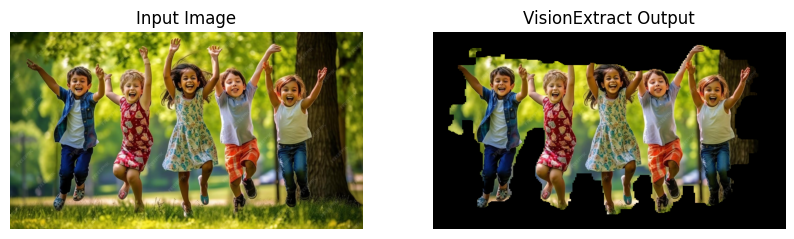

✅ Output saved to: isolated_subject.png


In [8]:
# Replace with the path o an image you just downloaded
test_image_path = "image4.avif"  # Update this to your actual image path
vision_extract_inference(test_image_path, model_final)

In [34]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import sys

# Force CPU usage
os.environ["CUDA_VISIBLE_DEVICES"] = "-1" 
os.environ["SM_FRAMEWORK"] = "tf.keras"

import segmentation_models as sm

# Add src to path to find your utils1.py
sys.path.append(os.path.abspath('../src'))
from utils1 import VisionExtractFineTuneGenerator

print("✅ Environment ready. Using CPU and FPN architecture.")

✅ Environment ready. Using CPU and FPN architecture.


In [37]:
import sys
import os

# This adds the 'src' directory to the path so the notebook can find utils1.py
sys.path.append(os.path.abspath('../src'))

# Now import the class from utils1.py
from utils1 import VisionExtractFineTuneGenerator

print("✅ VisionExtractFineTuneGenerator imported successfully!")

✅ VisionExtractFineTuneGenerator imported successfully!


In [38]:
# 1. Metric: Mean IoU with float32 casting
def mean_iou(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    sub_iou = sm.metrics.IOUScore(threshold=0.5)(y_true, y_pred)
    bg_iou = sm.metrics.IOUScore(threshold=0.5, class_indexes=0)(y_true, y_pred)
    return (sub_iou + bg_iou) / 2

# 2. Generator Wrapper for Preprocessing
class CPUOptimizedGenerator(VisionExtractFineTuneGenerator):
    def __getitem__(self, index):
        X, y = super().__getitem__(index)
        # MobileNetV2 expects [-1, 1]
        X = (X * 2.0) - 1.0 
        # Force float32 to prevent 'Mul' Op errors
        return X.astype('float32'), y.astype('float32')

# Initialize with Batch Size 4
preprocess_input = sm.get_preprocessing('mobilenetv2')
train_gen = CPUOptimizedGenerator('../data/processed/train', batch_size=4)
val_gen = CPUOptimizedGenerator('../data/processed/val', batch_size=4)

print("✅ Optimized Generators initialized.")

✅ Optimized Generators initialized.


In [36]:
BACKBONE = 'mobilenetv2'

# Build FPN Model
model = sm.FPN(
    BACKBONE, 
    encoder_weights='imagenet', 
    classes=1, 
    activation='sigmoid',
    input_shape=(256, 256, 3)
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=sm.losses.DiceLoss(),
    metrics=[
        sm.metrics.IOUScore(threshold=0.5, name='subject_iou'),
        sm.metrics.IOUScore(threshold=0.5, class_indexes=0, name='bg_iou'),
        mean_iou,
        'accuracy'
    ]
)

print("✅ FPN Model built and compiled.")

✅ FPN Model built and compiled.


🚀 Starting Training... Please keep laptop plugged into power.
Epoch 1/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7358 - bg_iou: 0.4681 - loss: 0.3833 - mean_iou: 0.4681 - subject_iou: 0.4681

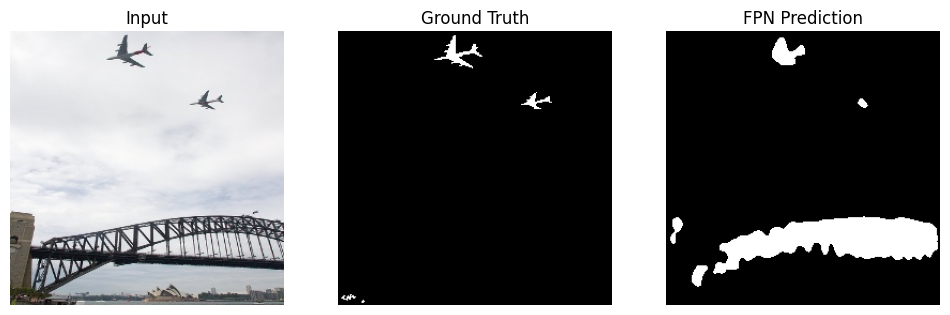


Epoch 1: val_mean_iou improved from None to 0.58217, saving model to models/fpn_visionextract_final.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 3035s 3s/step - accuracy: 0.7652 - bg_iou: 0.4840 - loss: 0.3642 - mean_iou: 0.4840 - subject_iou: 0.4840 - val_accuracy: 0.8312 - val_bg_iou: 0.5822 - val_loss: 0.2747 - val_mean_iou: 0.5822 - val_subject_iou: 0.5822
Epoch 2/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7970 - bg_iou: 0.5197 - loss: 0.3288 - mean_iou: 0.5197 - subject_iou: 0.5197

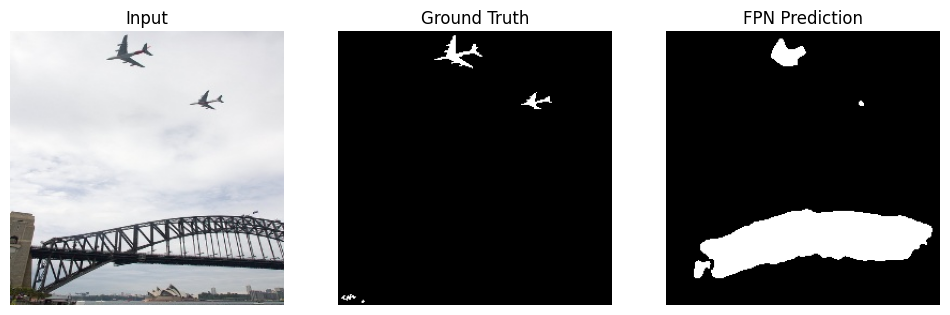


Epoch 2: val_mean_iou improved from 0.58217 to 0.59438, saving model to models/fpn_visionextract_final.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 3073s 4s/step - accuracy: 0.7985 - bg_iou: 0.5226 - loss: 0.3266 - mean_iou: 0.5226 - subject_iou: 0.5226 - val_accuracy: 0.8377 - val_bg_iou: 0.5944 - val_loss: 0.2643 - val_mean_iou: 0.5944 - val_subject_iou: 0.5944
Epoch 3/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8199 - bg_iou: 0.5510 - loss: 0.3019 - mean_iou: 0.5510 - subject_iou: 0.5510

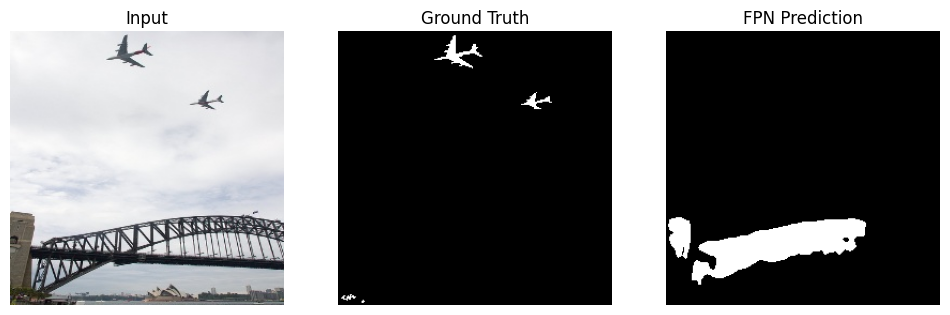


Epoch 3: val_mean_iou improved from 0.59438 to 0.60106, saving model to models/fpn_visionextract_final.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 3076s 4s/step - accuracy: 0.8180 - bg_iou: 0.5534 - loss: 0.2997 - mean_iou: 0.5534 - subject_iou: 0.5534 - val_accuracy: 0.8524 - val_bg_iou: 0.6011 - val_loss: 0.2601 - val_mean_iou: 0.6011 - val_subject_iou: 0.6011
Epoch 4/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8286 - bg_iou: 0.5737 - loss: 0.2841 - mean_iou: 0.5737 - subject_iou: 0.5737

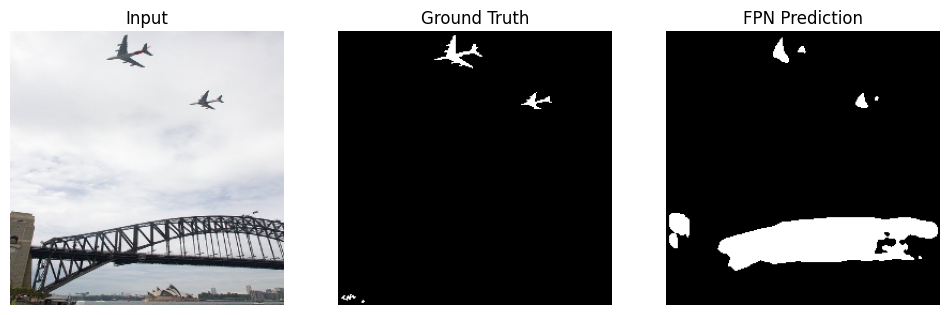


Epoch 4: val_mean_iou did not improve from 0.60106
875/875 ━━━━━━━━━━━━━━━━━━━━ 3054s 3s/step - accuracy: 0.8291 - bg_iou: 0.5740 - loss: 0.2832 - mean_iou: 0.5740 - subject_iou: 0.5740 - val_accuracy: 0.8388 - val_bg_iou: 0.5986 - val_loss: 0.2612 - val_mean_iou: 0.5986 - val_subject_iou: 0.5986
Epoch 5/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8409 - bg_iou: 0.5986 - loss: 0.2611 - mean_iou: 0.5986 - subject_iou: 0.5986

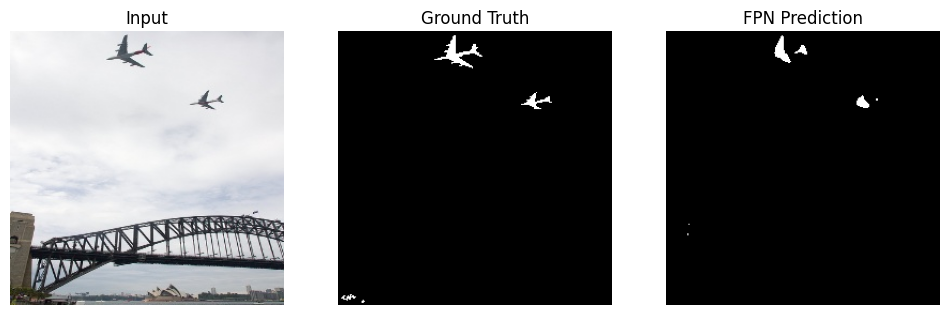


Epoch 5: val_mean_iou improved from 0.60106 to 0.60655, saving model to models/fpn_visionextract_final.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 2968s 3s/step - accuracy: 0.8387 - bg_iou: 0.5913 - loss: 0.2676 - mean_iou: 0.5913 - subject_iou: 0.5913 - val_accuracy: 0.8614 - val_bg_iou: 0.6065 - val_loss: 0.2556 - val_mean_iou: 0.6065 - val_subject_iou: 0.6065
Epoch 6/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8487 - bg_iou: 0.6177 - loss: 0.2462 - mean_iou: 0.6177 - subject_iou: 0.6177

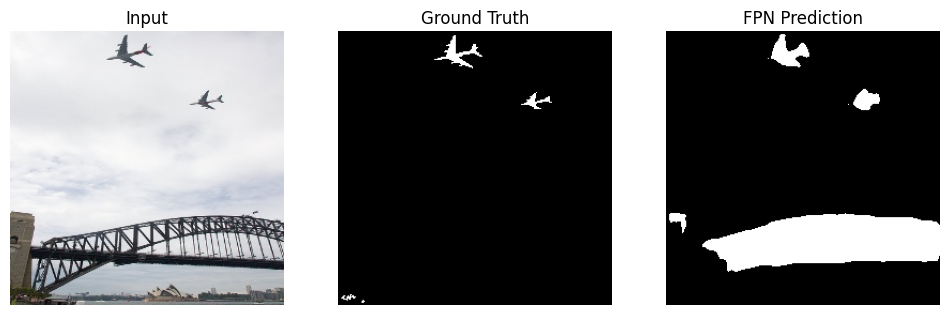


Epoch 6: val_mean_iou did not improve from 0.60655
875/875 ━━━━━━━━━━━━━━━━━━━━ 5136s 6s/step - accuracy: 0.8458 - bg_iou: 0.6032 - loss: 0.2577 - mean_iou: 0.6032 - subject_iou: 0.6032 - val_accuracy: 0.8201 - val_bg_iou: 0.5796 - val_loss: 0.2771 - val_mean_iou: 0.5796 - val_subject_iou: 0.5796
Epoch 7/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8547 - bg_iou: 0.6130 - loss: 0.2503 - mean_iou: 0.6130 - subject_iou: 0.6130

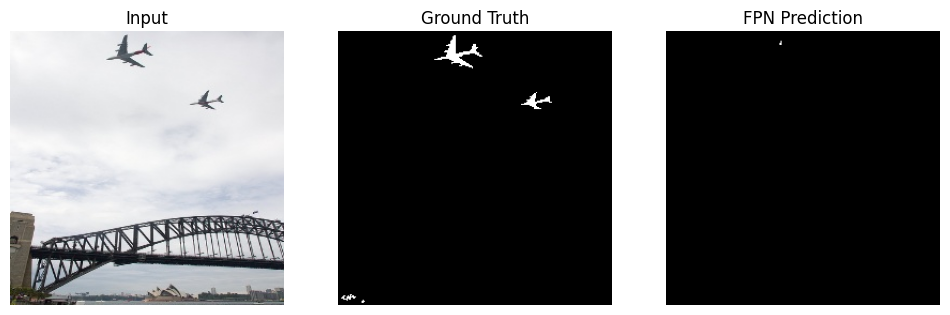


Epoch 7: val_mean_iou did not improve from 0.60655
875/875 ━━━━━━━━━━━━━━━━━━━━ 5921s 7s/step - accuracy: 0.8537 - bg_iou: 0.6162 - loss: 0.2474 - mean_iou: 0.6162 - subject_iou: 0.6162 - val_accuracy: 0.8402 - val_bg_iou: 0.6022 - val_loss: 0.2585 - val_mean_iou: 0.6022 - val_subject_iou: 0.6022
Epoch 8/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8547 - bg_iou: 0.6227 - loss: 0.2426 - mean_iou: 0.6227 - subject_iou: 0.6227

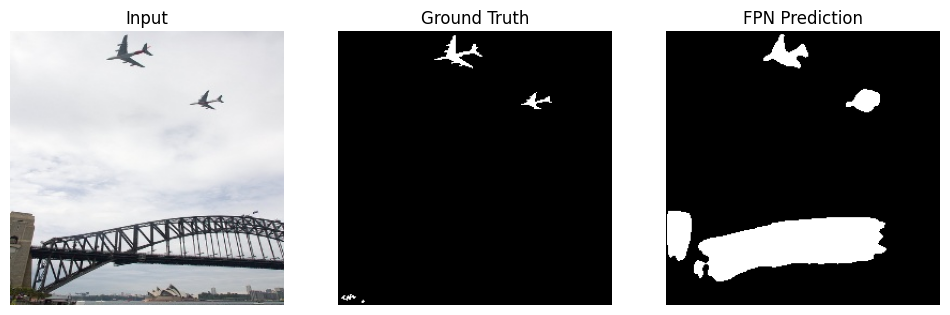


Epoch 8: val_mean_iou did not improve from 0.60655
875/875 ━━━━━━━━━━━━━━━━━━━━ 2984s 3s/step - accuracy: 0.8572 - bg_iou: 0.6235 - loss: 0.2418 - mean_iou: 0.6235 - subject_iou: 0.6235 - val_accuracy: 0.8367 - val_bg_iou: 0.5960 - val_loss: 0.2621 - val_mean_iou: 0.5960 - val_subject_iou: 0.5960
Epoch 9/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8609 - bg_iou: 0.6292 - loss: 0.2371 - mean_iou: 0.6292 - subject_iou: 0.6292

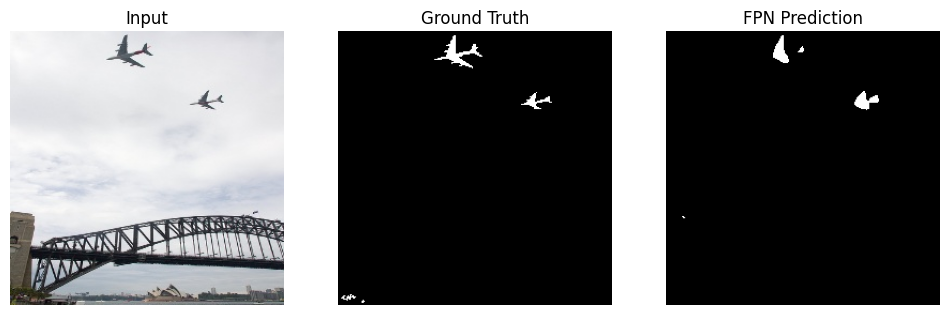


Epoch 9: val_mean_iou did not improve from 0.60655
875/875 ━━━━━━━━━━━━━━━━━━━━ 2933s 3s/step - accuracy: 0.8608 - bg_iou: 0.6296 - loss: 0.2365 - mean_iou: 0.6296 - subject_iou: 0.6296 - val_accuracy: 0.8507 - val_bg_iou: 0.5991 - val_loss: 0.2606 - val_mean_iou: 0.5991 - val_subject_iou: 0.5991
Epoch 10/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8626 - bg_iou: 0.6367 - loss: 0.2315 - mean_iou: 0.6367 - subject_iou: 0.6367

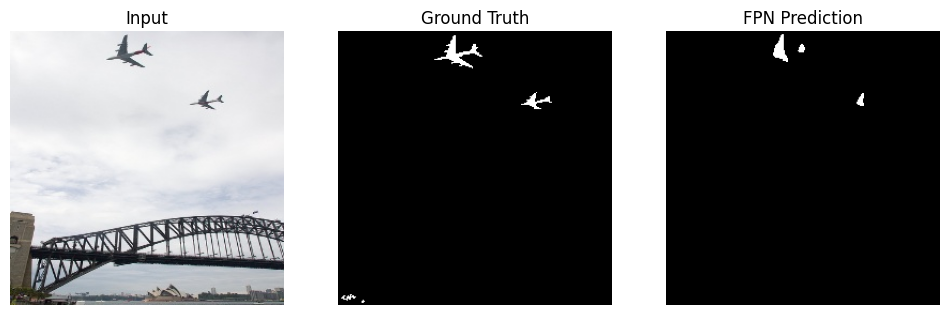


Epoch 10: val_mean_iou did not improve from 0.60655
875/875 ━━━━━━━━━━━━━━━━━━━━ 2943s 3s/step - accuracy: 0.8650 - bg_iou: 0.6384 - loss: 0.2302 - mean_iou: 0.6384 - subject_iou: 0.6384 - val_accuracy: 0.8540 - val_bg_iou: 0.5808 - val_loss: 0.2761 - val_mean_iou: 0.5808 - val_subject_iou: 0.5808
Epoch 11/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8698 - bg_iou: 0.6474 - loss: 0.2232 - mean_iou: 0.6474 - subject_iou: 0.6474

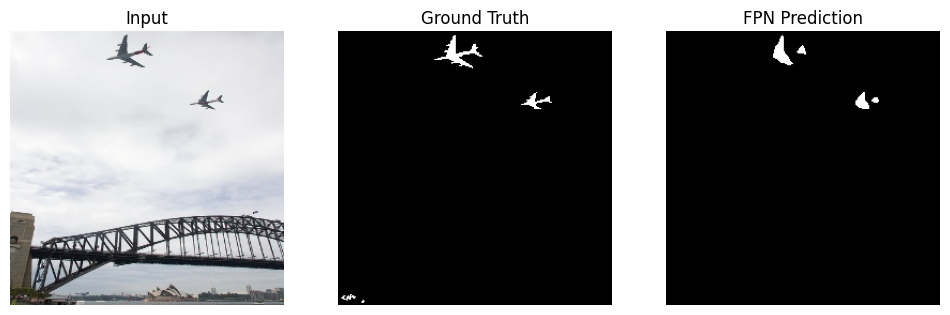


Epoch 11: val_mean_iou did not improve from 0.60655
875/875 ━━━━━━━━━━━━━━━━━━━━ 3061s 3s/step - accuracy: 0.8687 - bg_iou: 0.6460 - loss: 0.2244 - mean_iou: 0.6460 - subject_iou: 0.6460 - val_accuracy: 0.8531 - val_bg_iou: 0.5918 - val_loss: 0.2669 - val_mean_iou: 0.5918 - val_subject_iou: 0.5918
Epoch 12/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8720 - bg_iou: 0.6469 - loss: 0.2239 - mean_iou: 0.6469 - subject_iou: 0.6469

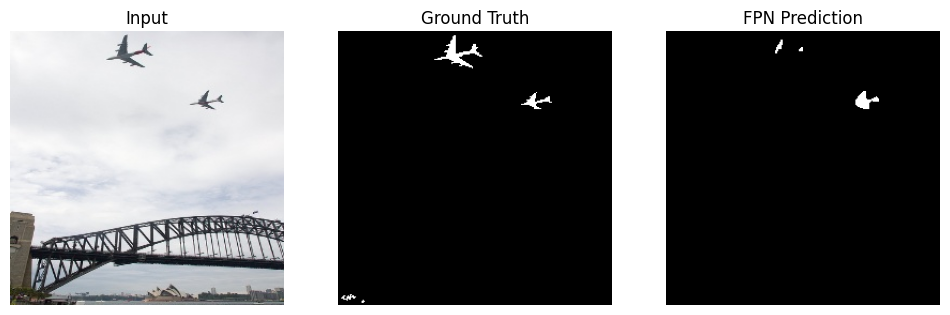


Epoch 12: val_mean_iou did not improve from 0.60655
875/875 ━━━━━━━━━━━━━━━━━━━━ 3109s 4s/step - accuracy: 0.8695 - bg_iou: 0.6463 - loss: 0.2240 - mean_iou: 0.6463 - subject_iou: 0.6463 - val_accuracy: 0.8393 - val_bg_iou: 0.5933 - val_loss: 0.2651 - val_mean_iou: 0.5933 - val_subject_iou: 0.5933
Epoch 13/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8788 - bg_iou: 0.6631 - loss: 0.2110 - mean_iou: 0.6631 - subject_iou: 0.6631

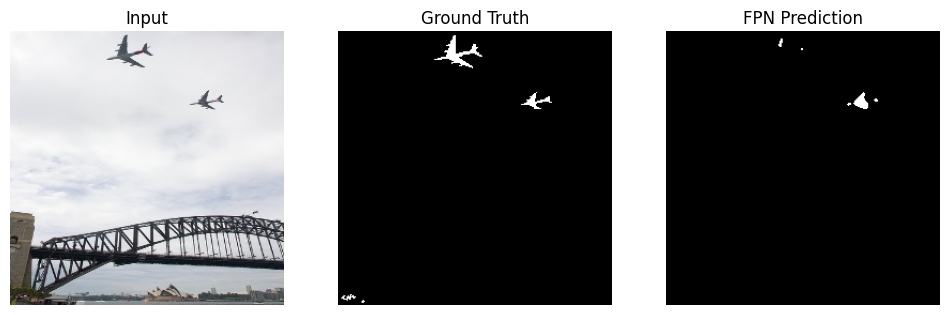


Epoch 13: val_mean_iou did not improve from 0.60655
875/875 ━━━━━━━━━━━━━━━━━━━━ 2974s 3s/step - accuracy: 0.8738 - bg_iou: 0.6556 - loss: 0.2168 - mean_iou: 0.6556 - subject_iou: 0.6556 - val_accuracy: 0.8467 - val_bg_iou: 0.5569 - val_loss: 0.2963 - val_mean_iou: 0.5569 - val_subject_iou: 0.5569
Epoch 14/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8764 - bg_iou: 0.6570 - loss: 0.2166 - mean_iou: 0.6570 - subject_iou: 0.6570

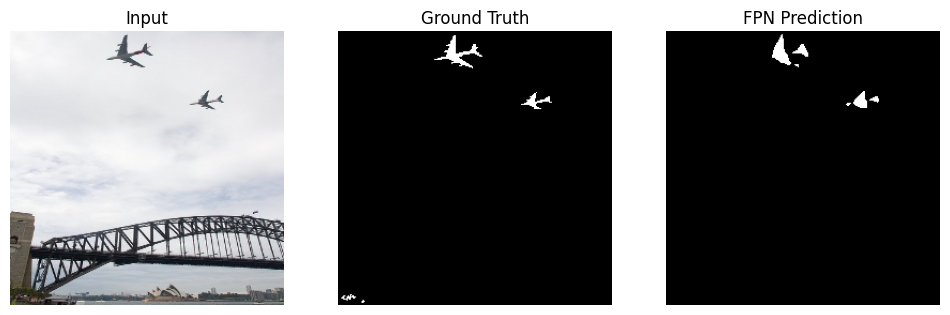


Epoch 14: val_mean_iou did not improve from 0.60655
875/875 ━━━━━━━━━━━━━━━━━━━━ 3077s 4s/step - accuracy: 0.8765 - bg_iou: 0.6612 - loss: 0.2123 - mean_iou: 0.6612 - subject_iou: 0.6612 - val_accuracy: 0.8450 - val_bg_iou: 0.5922 - val_loss: 0.2658 - val_mean_iou: 0.5922 - val_subject_iou: 0.5922
Epoch 15/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8786 - bg_iou: 0.6624 - loss: 0.2115 - mean_iou: 0.6624 - subject_iou: 0.6624

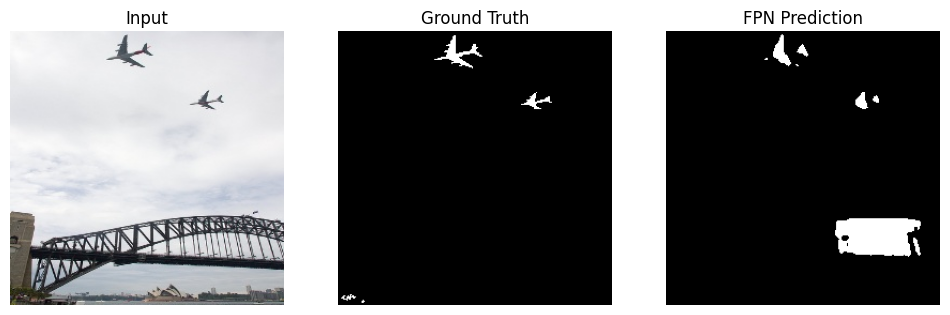


Epoch 15: val_mean_iou did not improve from 0.60655
875/875 ━━━━━━━━━━━━━━━━━━━━ 3107s 4s/step - accuracy: 0.8780 - bg_iou: 0.6648 - loss: 0.2093 - mean_iou: 0.6648 - subject_iou: 0.6648 - val_accuracy: 0.8469 - val_bg_iou: 0.5801 - val_loss: 0.2756 - val_mean_iou: 0.5801 - val_subject_iou: 0.5801
Epoch 16/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8813 - bg_iou: 0.6674 - loss: 0.2075 - mean_iou: 0.6674 - subject_iou: 0.6674

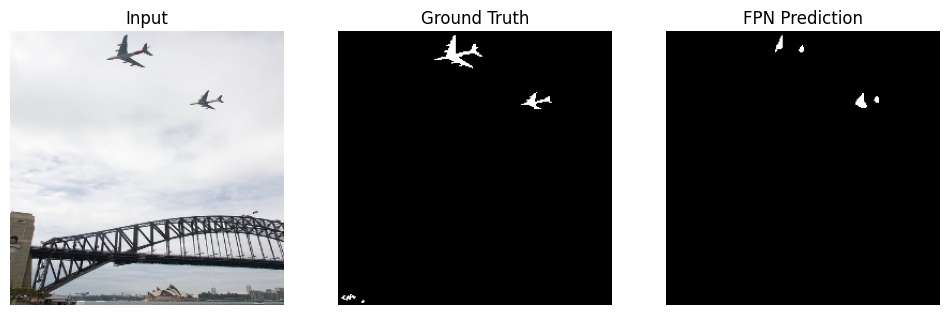


Epoch 16: val_mean_iou did not improve from 0.60655
875/875 ━━━━━━━━━━━━━━━━━━━━ 3020s 3s/step - accuracy: 0.8805 - bg_iou: 0.6681 - loss: 0.2069 - mean_iou: 0.6681 - subject_iou: 0.6681 - val_accuracy: 0.8533 - val_bg_iou: 0.5797 - val_loss: 0.2768 - val_mean_iou: 0.5797 - val_subject_iou: 0.5797
Epoch 17/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8802 - bg_iou: 0.6657 - loss: 0.2089 - mean_iou: 0.6657 - subject_iou: 0.6657

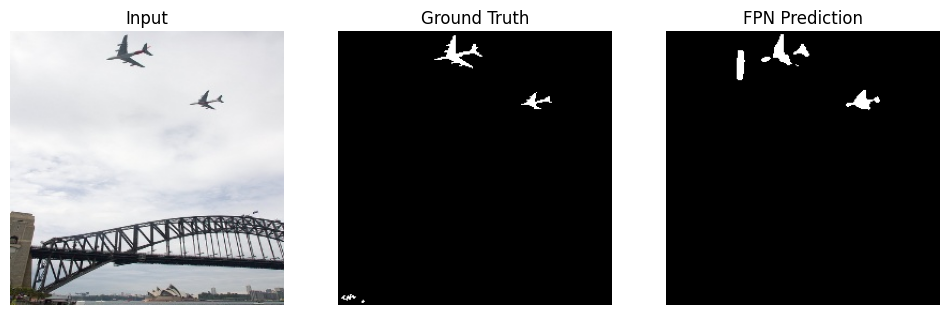


Epoch 17: val_mean_iou did not improve from 0.60655
875/875 ━━━━━━━━━━━━━━━━━━━━ 3101s 4s/step - accuracy: 0.8792 - bg_iou: 0.6652 - loss: 0.2092 - mean_iou: 0.6652 - subject_iou: 0.6652 - val_accuracy: 0.8512 - val_bg_iou: 0.5925 - val_loss: 0.2658 - val_mean_iou: 0.5925 - val_subject_iou: 0.5925
Epoch 18/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8846 - bg_iou: 0.6686 - loss: 0.2075 - mean_iou: 0.6686 - subject_iou: 0.6686

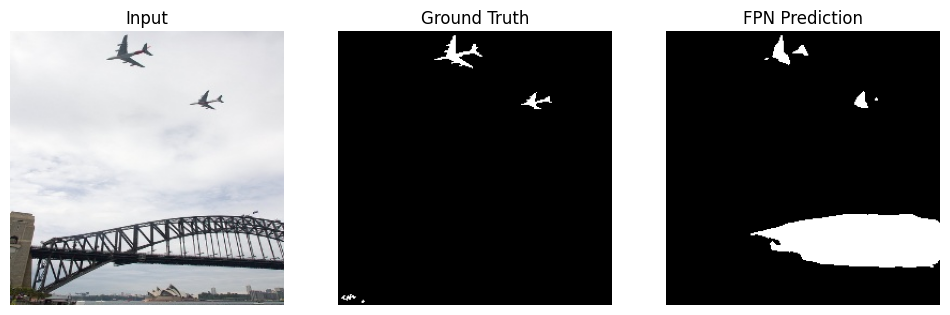


Epoch 18: val_mean_iou did not improve from 0.60655
875/875 ━━━━━━━━━━━━━━━━━━━━ 3141s 4s/step - accuracy: 0.8844 - bg_iou: 0.6751 - loss: 0.2020 - mean_iou: 0.6751 - subject_iou: 0.6751 - val_accuracy: 0.8283 - val_bg_iou: 0.5801 - val_loss: 0.2759 - val_mean_iou: 0.5801 - val_subject_iou: 0.5801
Epoch 19/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8886 - bg_iou: 0.6862 - loss: 0.1939 - mean_iou: 0.6862 - subject_iou: 0.6862

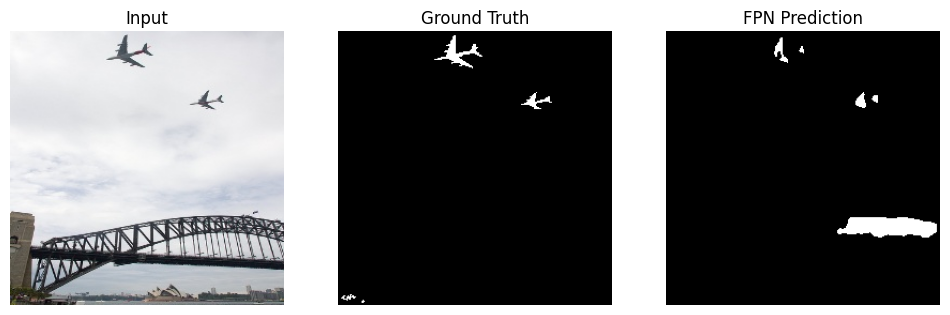


Epoch 19: val_mean_iou did not improve from 0.60655
875/875 ━━━━━━━━━━━━━━━━━━━━ 3092s 4s/step - accuracy: 0.8897 - bg_iou: 0.6874 - loss: 0.1926 - mean_iou: 0.6874 - subject_iou: 0.6874 - val_accuracy: 0.8496 - val_bg_iou: 0.5551 - val_loss: 0.2966 - val_mean_iou: 0.5551 - val_subject_iou: 0.5551
Epoch 20/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8848 - bg_iou: 0.6798 - loss: 0.1978 - mean_iou: 0.6798 - subject_iou: 0.6798

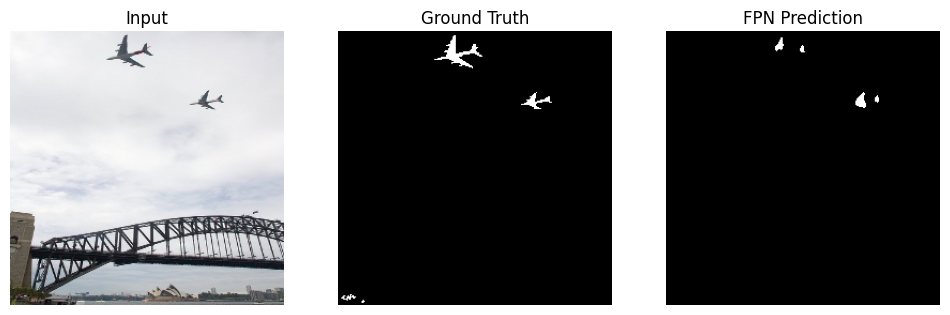


Epoch 20: val_mean_iou did not improve from 0.60655
875/875 ━━━━━━━━━━━━━━━━━━━━ 3117s 4s/step - accuracy: 0.8869 - bg_iou: 0.6813 - loss: 0.1970 - mean_iou: 0.6813 - subject_iou: 0.6813 - val_accuracy: 0.8513 - val_bg_iou: 0.5829 - val_loss: 0.2741 - val_mean_iou: 0.5829 - val_subject_iou: 0.5829


In [39]:
# 1. Callbacks
if not os.path.exists('models'): os.makedirs('models')

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'models/fpn_visionextract_final.keras', 
    monitor='val_mean_iou', 
    save_best_only=True, 
    mode='max', 
    verbose=1
)

class VisualizeProgress(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        x_batch, y_batch = val_gen[0]
        preds = self.model.predict(x_batch, verbose=0)
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1); plt.imshow((x_batch[0] + 1) / 2); plt.title("Input"); plt.axis('off')
        plt.subplot(1, 3, 2); plt.imshow(y_batch[0].squeeze(), cmap='gray'); plt.title("Ground Truth"); plt.axis('off')
        plt.subplot(1, 3, 3); plt.imshow((preds[0] > 0.5).astype(np.uint8).squeeze(), cmap='gray'); plt.title("FPN Prediction"); plt.axis('off')
        plt.show()

# 2. Run Training
print("🚀 Starting Training... Please keep laptop plugged into power.")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20, 
    callbacks=[VisualizeProgress(), checkpoint],
    verbose=1
)

In [43]:
class AugmentedCPUGenerator(VisionExtractFineTuneGenerator):
    def __getitem__(self, index):
        X, y = super().__getitem__(index)
        X_aug, y_aug = [], []

        for i in range(len(X)):
            # Ensure we start with standard 256x256 shapes
            img = cv2.resize(X[i], (256, 256))
            mask = cv2.resize(y[i], (256, 256))

            choice = np.random.choice(['none', 'flip', 'rotate', 'both'])

            if choice == 'flip':
                img = cv2.flip(img, 1)
                mask = cv2.flip(mask, 1)
            
            elif choice == 'rotate':
                angle = np.random.uniform(-30, 30)
                M = cv2.getRotationMatrix2D((128, 128), angle, 1.0)
                img = cv2.warpAffine(img, M, (256, 256), flags=cv2.INTER_LINEAR)
                mask = cv2.warpAffine(mask, M, (256, 256), flags=cv2.INTER_NEAREST)

            elif choice == 'both':
                img = cv2.flip(img, 1)
                mask = cv2.flip(mask, 1)
                angle = np.random.uniform(-15, 15)
                M = cv2.getRotationMatrix2D((128, 128), angle, 1.0)
                img = cv2.warpAffine(img, M, (256, 256), flags=cv2.INTER_LINEAR)
                mask = cv2.warpAffine(mask, M, (256, 256), flags=cv2.INTER_NEAREST)

            # CRITICAL FIX: Force specific shapes
            img = img.reshape(256, 256, 3)
            mask = (mask > 0.5).astype(np.float32).reshape(256, 256, 1)
            
            # MobileNetV2 Preprocessing
            img = (img * 2.0) - 1.0

            X_aug.append(img.astype('float32'))
            y_aug.append(mask.astype('float32'))

        return np.array(X_aug), np.array(y_aug)

# RE-RUN THIS AFTER REDEFINING THE CLASS
train_gen = AugmentedCPUGenerator('../data/processed/train', batch_size=4)
val_gen = AugmentedCPUGenerator('../data/processed/val', batch_size=4)

In [44]:
# Re-compile with the ultra-fine learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss=sm.losses.DiceLoss(),
    metrics=[
        sm.metrics.IOUScore(threshold=0.5, name='subject_iou'),
        sm.metrics.IOUScore(threshold=0.5, class_indexes=0, name='bg_iou'),
        mean_iou,
        'accuracy'
    ]
)

print("🚀 Model ready for fine-tuning!")

🚀 Model ready for fine-tuning!


🚀 Starting Fine-Tuning with 1e-5 learning rate and Augmentation...
Epoch 1/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8359 - bg_iou: 0.5746 - loss: 0.2817 - mean_iou: 0.5746 - subject_iou: 0.5746

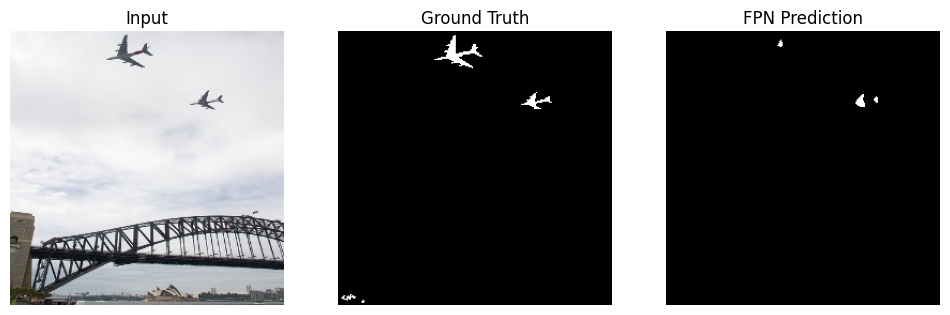


Epoch 1: val_subject_iou improved from None to 0.52515, saving model to models/fpn_visionextract_finetuned.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 2880s 3s/step - accuracy: 0.8369 - bg_iou: 0.5752 - loss: 0.2810 - mean_iou: 0.5752 - subject_iou: 0.5752 - val_accuracy: 0.8218 - val_bg_iou: 0.5252 - val_loss: 0.3217 - val_mean_iou: 0.5252 - val_subject_iou: 0.5252
Epoch 2/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8400 - bg_iou: 0.5798 - loss: 0.2777 - mean_iou: 0.5798 - subject_iou: 0.5798

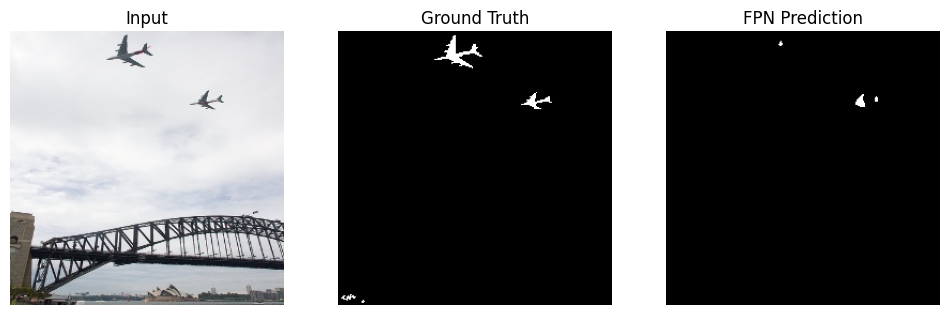


Epoch 2: val_subject_iou improved from 0.52515 to 0.52906, saving model to models/fpn_visionextract_finetuned.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 3118s 4s/step - accuracy: 0.8415 - bg_iou: 0.5836 - loss: 0.2738 - mean_iou: 0.5836 - subject_iou: 0.5836 - val_accuracy: 0.8235 - val_bg_iou: 0.5291 - val_loss: 0.3183 - val_mean_iou: 0.5291 - val_subject_iou: 0.5291
Epoch 3/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8460 - bg_iou: 0.5929 - loss: 0.2649 - mean_iou: 0.5929 - subject_iou: 0.5929

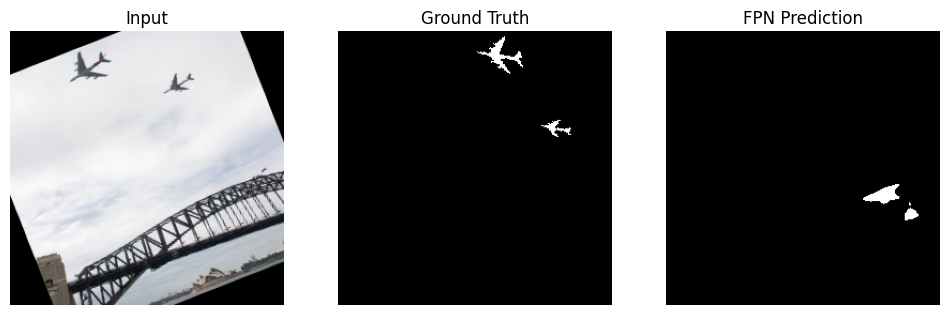


Epoch 3: val_subject_iou improved from 0.52906 to 0.52914, saving model to models/fpn_visionextract_finetuned.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 3728s 4s/step - accuracy: 0.8498 - bg_iou: 0.5984 - loss: 0.2607 - mean_iou: 0.5984 - subject_iou: 0.5984 - val_accuracy: 0.8262 - val_bg_iou: 0.5291 - val_loss: 0.3174 - val_mean_iou: 0.5291 - val_subject_iou: 0.5291
Epoch 4/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8449 - bg_iou: 0.5923 - loss: 0.2658 - mean_iou: 0.5923 - subject_iou: 0.5923

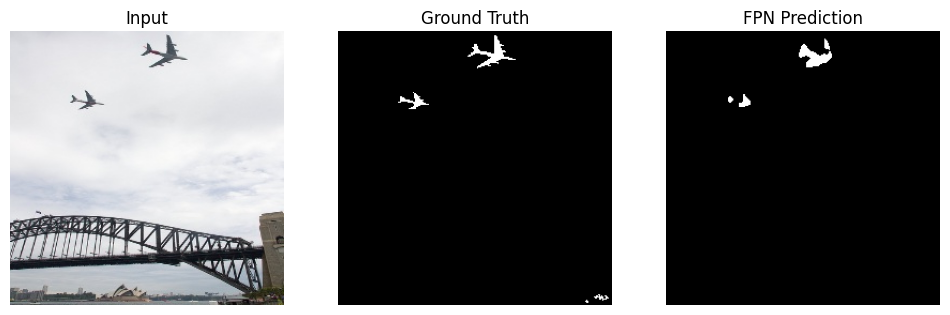


Epoch 4: val_subject_iou improved from 0.52914 to 0.54757, saving model to models/fpn_visionextract_finetuned.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 3187s 4s/step - accuracy: 0.8459 - bg_iou: 0.5926 - loss: 0.2657 - mean_iou: 0.5926 - subject_iou: 0.5926 - val_accuracy: 0.8318 - val_bg_iou: 0.5476 - val_loss: 0.3037 - val_mean_iou: 0.5476 - val_subject_iou: 0.5476
Epoch 5/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8499 - bg_iou: 0.5957 - loss: 0.2638 - mean_iou: 0.5957 - subject_iou: 0.5957

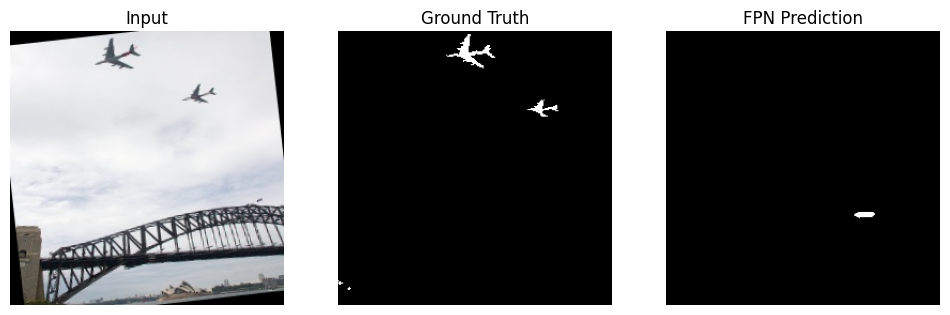


Epoch 5: val_subject_iou did not improve from 0.54757
875/875 ━━━━━━━━━━━━━━━━━━━━ 3169s 4s/step - accuracy: 0.8486 - bg_iou: 0.5967 - loss: 0.2628 - mean_iou: 0.5967 - subject_iou: 0.5967 - val_accuracy: 0.8244 - val_bg_iou: 0.5331 - val_loss: 0.3152 - val_mean_iou: 0.5331 - val_subject_iou: 0.5331
Epoch 6/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8514 - bg_iou: 0.5984 - loss: 0.2616 - mean_iou: 0.5984 - subject_iou: 0.5984

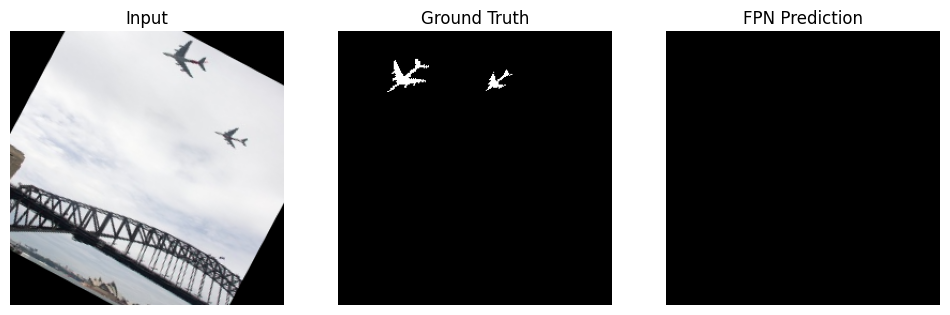


Epoch 6: val_subject_iou did not improve from 0.54757
875/875 ━━━━━━━━━━━━━━━━━━━━ 3200s 4s/step - accuracy: 0.8480 - bg_iou: 0.5946 - loss: 0.2646 - mean_iou: 0.5946 - subject_iou: 0.5946 - val_accuracy: 0.8281 - val_bg_iou: 0.5363 - val_loss: 0.3131 - val_mean_iou: 0.5363 - val_subject_iou: 0.5363
Epoch 7/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8549 - bg_iou: 0.6075 - loss: 0.2551 - mean_iou: 0.6075 - subject_iou: 0.6075

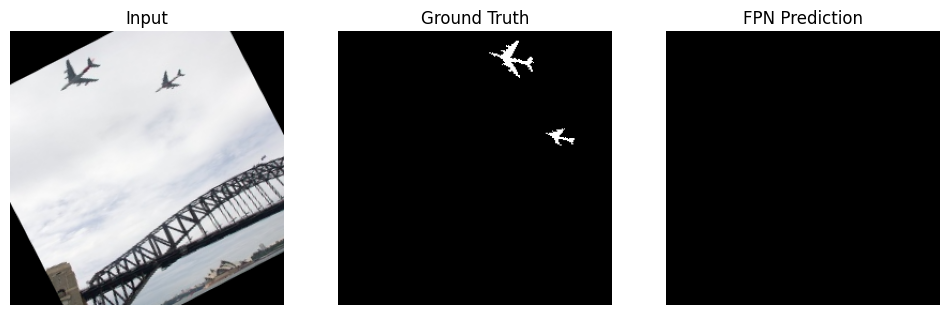


Epoch 7: val_subject_iou did not improve from 0.54757
875/875 ━━━━━━━━━━━━━━━━━━━━ 2898s 3s/step - accuracy: 0.8511 - bg_iou: 0.5982 - loss: 0.2615 - mean_iou: 0.5982 - subject_iou: 0.5982 - val_accuracy: 0.8284 - val_bg_iou: 0.5315 - val_loss: 0.3168 - val_mean_iou: 0.5315 - val_subject_iou: 0.5315
Epoch 8/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8515 - bg_iou: 0.5933 - loss: 0.2659 - mean_iou: 0.5933 - subject_iou: 0.5933

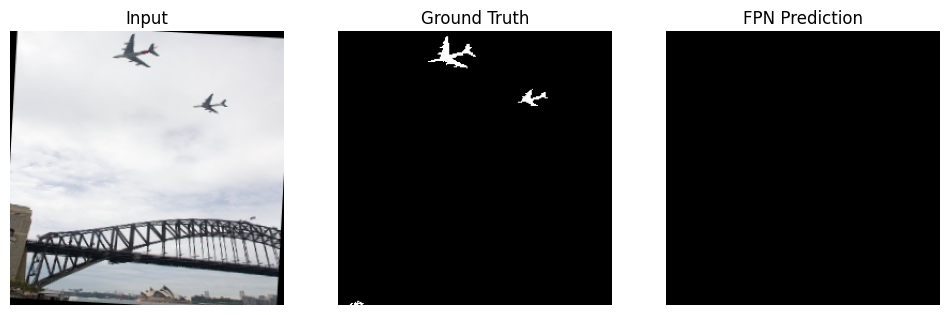


Epoch 8: val_subject_iou did not improve from 0.54757
875/875 ━━━━━━━━━━━━━━━━━━━━ 3167s 4s/step - accuracy: 0.8504 - bg_iou: 0.5966 - loss: 0.2626 - mean_iou: 0.5966 - subject_iou: 0.5966 - val_accuracy: 0.8304 - val_bg_iou: 0.5400 - val_loss: 0.3090 - val_mean_iou: 0.5400 - val_subject_iou: 0.5400
Epoch 9/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8501 - bg_iou: 0.6014 - loss: 0.2590 - mean_iou: 0.6014 - subject_iou: 0.6014

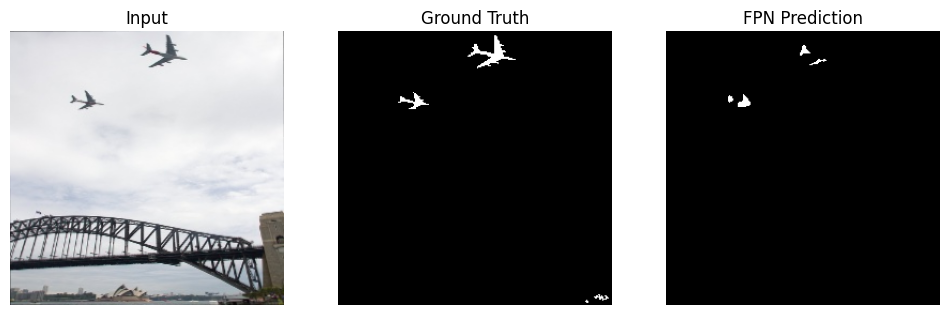


Epoch 9: val_subject_iou did not improve from 0.54757
875/875 ━━━━━━━━━━━━━━━━━━━━ 2934s 3s/step - accuracy: 0.8506 - bg_iou: 0.6010 - loss: 0.2591 - mean_iou: 0.6010 - subject_iou: 0.6010 - val_accuracy: 0.8311 - val_bg_iou: 0.5376 - val_loss: 0.3107 - val_mean_iou: 0.5376 - val_subject_iou: 0.5376
Epoch 10/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8532 - bg_iou: 0.5969 - loss: 0.2632 - mean_iou: 0.5969 - subject_iou: 0.5969

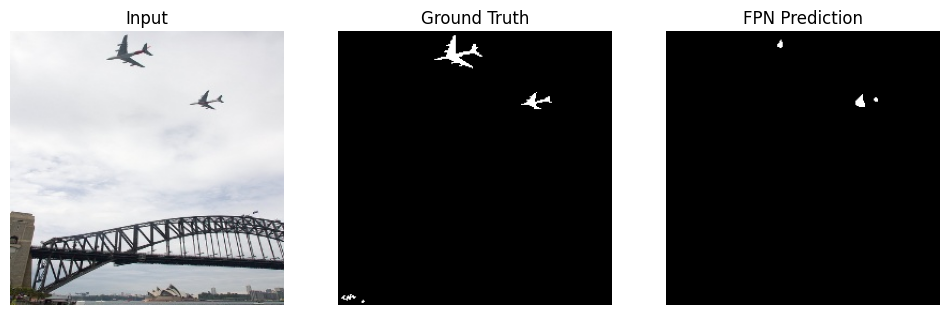


Epoch 10: val_subject_iou did not improve from 0.54757
875/875 ━━━━━━━━━━━━━━━━━━━━ 2989s 3s/step - accuracy: 0.8544 - bg_iou: 0.6049 - loss: 0.2558 - mean_iou: 0.6049 - subject_iou: 0.6049 - val_accuracy: 0.8284 - val_bg_iou: 0.5275 - val_loss: 0.3195 - val_mean_iou: 0.5275 - val_subject_iou: 0.5275
Epoch 11/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8572 - bg_iou: 0.6059 - loss: 0.2546 - mean_iou: 0.6059 - subject_iou: 0.6059

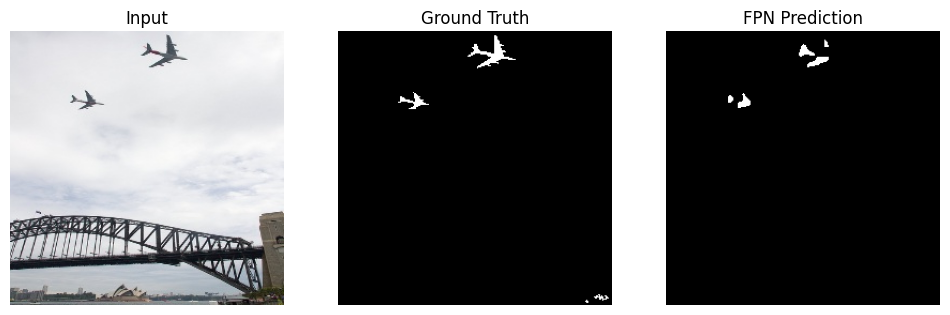


Epoch 11: val_subject_iou did not improve from 0.54757
875/875 ━━━━━━━━━━━━━━━━━━━━ 2930s 3s/step - accuracy: 0.8532 - bg_iou: 0.6040 - loss: 0.2568 - mean_iou: 0.6040 - subject_iou: 0.6040 - val_accuracy: 0.8264 - val_bg_iou: 0.5322 - val_loss: 0.3155 - val_mean_iou: 0.5322 - val_subject_iou: 0.5322
Epoch 12/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8532 - bg_iou: 0.6015 - loss: 0.2580 - mean_iou: 0.6015 - subject_iou: 0.6015

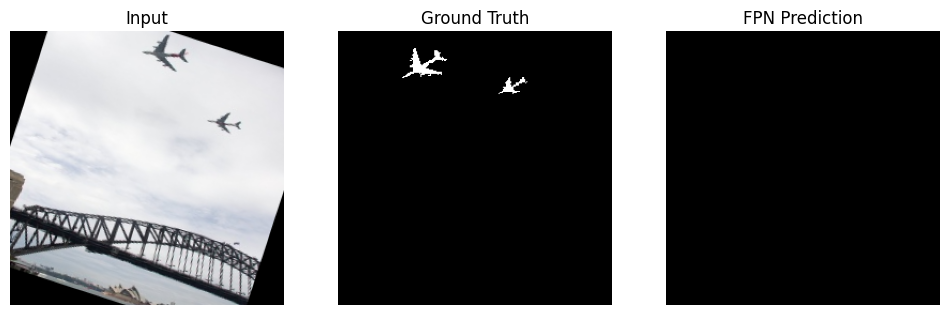


Epoch 12: val_subject_iou did not improve from 0.54757
875/875 ━━━━━━━━━━━━━━━━━━━━ 2904s 3s/step - accuracy: 0.8555 - bg_iou: 0.6065 - loss: 0.2544 - mean_iou: 0.6065 - subject_iou: 0.6065 - val_accuracy: 0.8286 - val_bg_iou: 0.5320 - val_loss: 0.3153 - val_mean_iou: 0.5320 - val_subject_iou: 0.5320
Epoch 13/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8499 - bg_iou: 0.5946 - loss: 0.2649 - mean_iou: 0.5946 - subject_iou: 0.5946

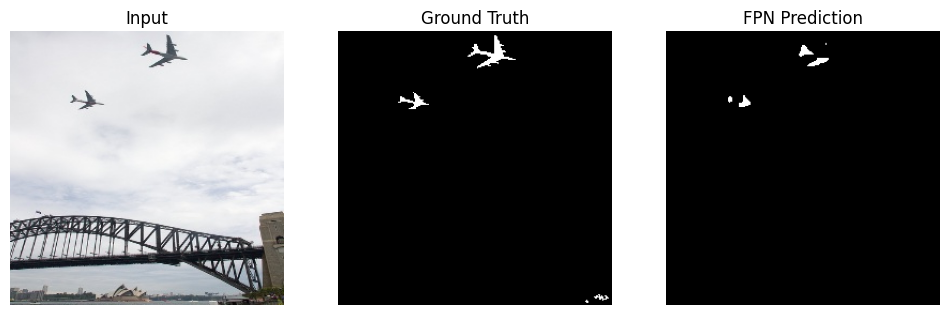


Epoch 13: val_subject_iou did not improve from 0.54757
875/875 ━━━━━━━━━━━━━━━━━━━━ 7357s 8s/step - accuracy: 0.8530 - bg_iou: 0.6017 - loss: 0.2583 - mean_iou: 0.6017 - subject_iou: 0.6017 - val_accuracy: 0.8281 - val_bg_iou: 0.5233 - val_loss: 0.3237 - val_mean_iou: 0.5233 - val_subject_iou: 0.5233
Epoch 14/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8572 - bg_iou: 0.6052 - loss: 0.2555 - mean_iou: 0.6052 - subject_iou: 0.6052

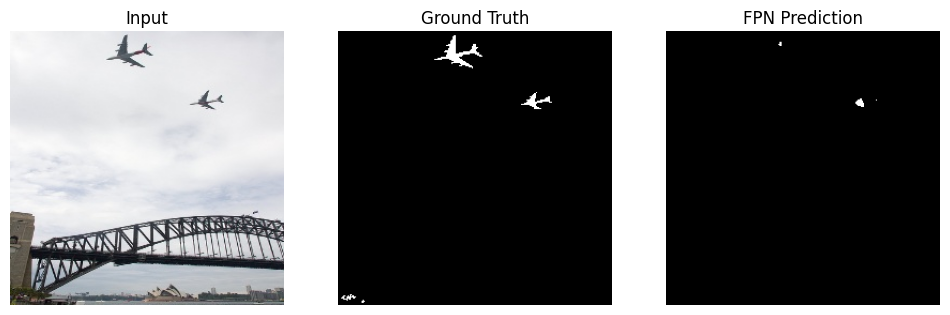


Epoch 14: val_subject_iou did not improve from 0.54757
875/875 ━━━━━━━━━━━━━━━━━━━━ 2876s 3s/step - accuracy: 0.8569 - bg_iou: 0.6097 - loss: 0.2517 - mean_iou: 0.6097 - subject_iou: 0.6097 - val_accuracy: 0.8295 - val_bg_iou: 0.5359 - val_loss: 0.3115 - val_mean_iou: 0.5359 - val_subject_iou: 0.5359
Epoch 15/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8511 - bg_iou: 0.5989 - loss: 0.2603 - mean_iou: 0.5989 - subject_iou: 0.5989

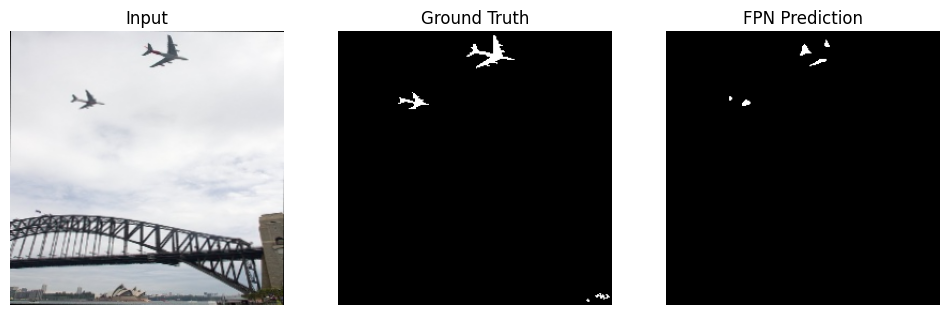


Epoch 15: val_subject_iou did not improve from 0.54757
875/875 ━━━━━━━━━━━━━━━━━━━━ 2920s 3s/step - accuracy: 0.8543 - bg_iou: 0.6029 - loss: 0.2574 - mean_iou: 0.6029 - subject_iou: 0.6029 - val_accuracy: 0.8330 - val_bg_iou: 0.5363 - val_loss: 0.3125 - val_mean_iou: 0.5363 - val_subject_iou: 0.5363
Epoch 16/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8540 - bg_iou: 0.5967 - loss: 0.2629 - mean_iou: 0.5967 - subject_iou: 0.5967

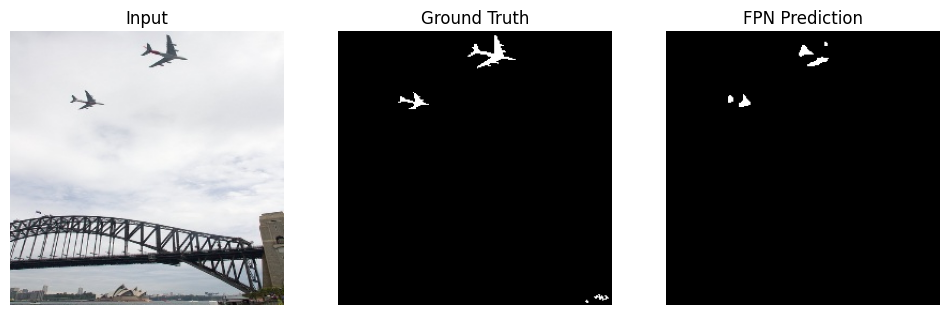


Epoch 16: val_subject_iou did not improve from 0.54757
875/875 ━━━━━━━━━━━━━━━━━━━━ 3001s 3s/step - accuracy: 0.8556 - bg_iou: 0.6057 - loss: 0.2557 - mean_iou: 0.6057 - subject_iou: 0.6057 - val_accuracy: 0.8278 - val_bg_iou: 0.5310 - val_loss: 0.3160 - val_mean_iou: 0.5310 - val_subject_iou: 0.5310
Epoch 17/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8484 - bg_iou: 0.5970 - loss: 0.2621 - mean_iou: 0.5970 - subject_iou: 0.5970

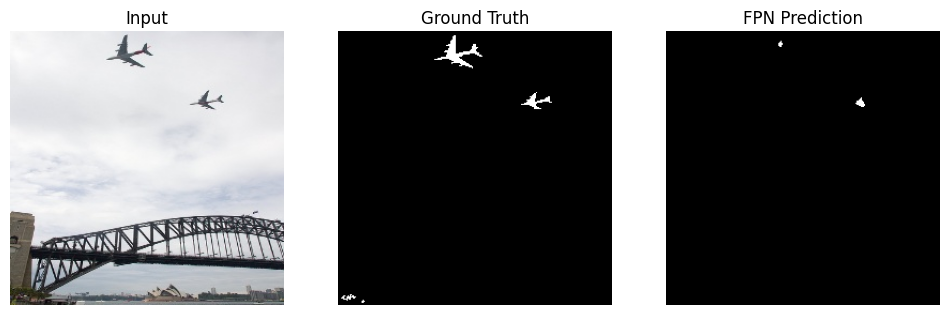


Epoch 17: val_subject_iou did not improve from 0.54757
875/875 ━━━━━━━━━━━━━━━━━━━━ 3138s 4s/step - accuracy: 0.8566 - bg_iou: 0.6104 - loss: 0.2513 - mean_iou: 0.6104 - subject_iou: 0.6104 - val_accuracy: 0.8274 - val_bg_iou: 0.5240 - val_loss: 0.3222 - val_mean_iou: 0.5240 - val_subject_iou: 0.5240
Epoch 18/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8545 - bg_iou: 0.6068 - loss: 0.2545 - mean_iou: 0.6068 - subject_iou: 0.6068

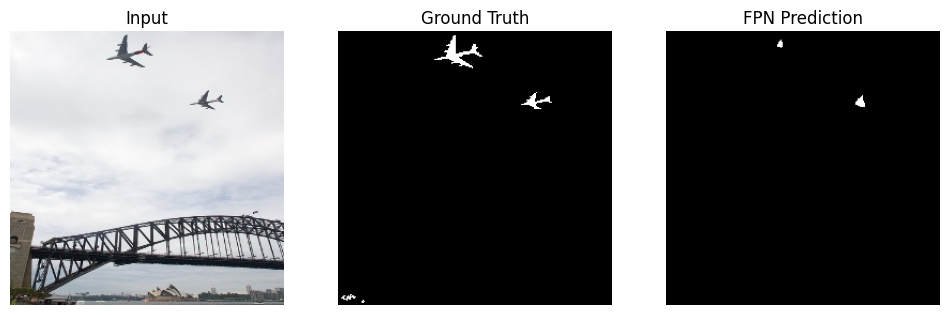


Epoch 18: val_subject_iou did not improve from 0.54757
875/875 ━━━━━━━━━━━━━━━━━━━━ 3127s 4s/step - accuracy: 0.8558 - bg_iou: 0.6070 - loss: 0.2541 - mean_iou: 0.6070 - subject_iou: 0.6070 - val_accuracy: 0.8289 - val_bg_iou: 0.5298 - val_loss: 0.3192 - val_mean_iou: 0.5298 - val_subject_iou: 0.5298
Epoch 19/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8564 - bg_iou: 0.6090 - loss: 0.2528 - mean_iou: 0.6090 - subject_iou: 0.6090

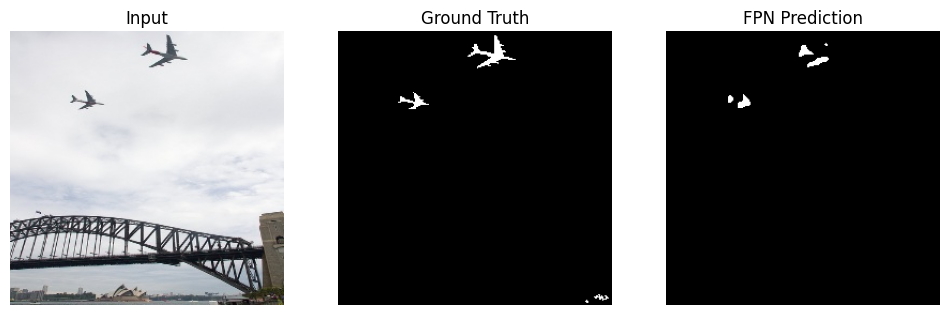


Epoch 19: val_subject_iou did not improve from 0.54757
875/875 ━━━━━━━━━━━━━━━━━━━━ 3254s 4s/step - accuracy: 0.8575 - bg_iou: 0.6125 - loss: 0.2498 - mean_iou: 0.6125 - subject_iou: 0.6125 - val_accuracy: 0.8279 - val_bg_iou: 0.5341 - val_loss: 0.3133 - val_mean_iou: 0.5341 - val_subject_iou: 0.5341
Epoch 20/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8551 - bg_iou: 0.6033 - loss: 0.2568 - mean_iou: 0.6033 - subject_iou: 0.6033

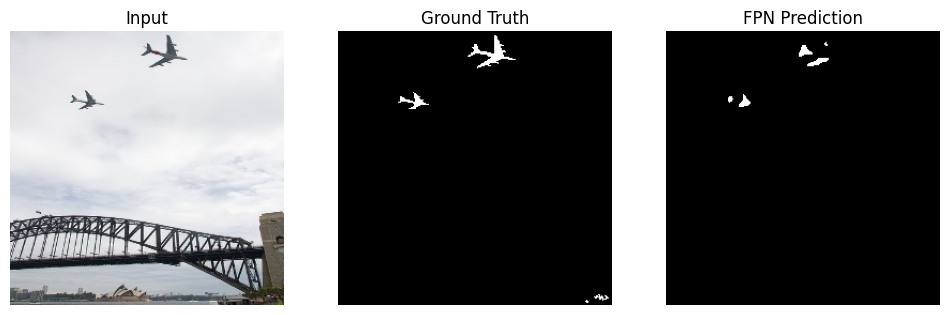


Epoch 20: val_subject_iou did not improve from 0.54757
875/875 ━━━━━━━━━━━━━━━━━━━━ 3086s 4s/step - accuracy: 0.8562 - bg_iou: 0.6076 - loss: 0.2537 - mean_iou: 0.6076 - subject_iou: 0.6076 - val_accuracy: 0.8272 - val_bg_iou: 0.5328 - val_loss: 0.3157 - val_mean_iou: 0.5328 - val_subject_iou: 0.5328


In [45]:
# 1. Update the checkpoint to save as a 'fine_tuned' version
checkpoint_ft = tf.keras.callbacks.ModelCheckpoint(
    'models/fpn_visionextract_finetuned.keras', 
    monitor='val_subject_iou', # We focus on the Plane IoU now!
    save_best_only=True, 
    mode='max', 
    verbose=1
)

# 2. Start Training (20 more epochs)
print("🚀 Starting Fine-Tuning with 1e-5 learning rate and Augmentation...")
history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20, 
    callbacks=[VisualizeProgress(), checkpoint_ft],
    verbose=1
)

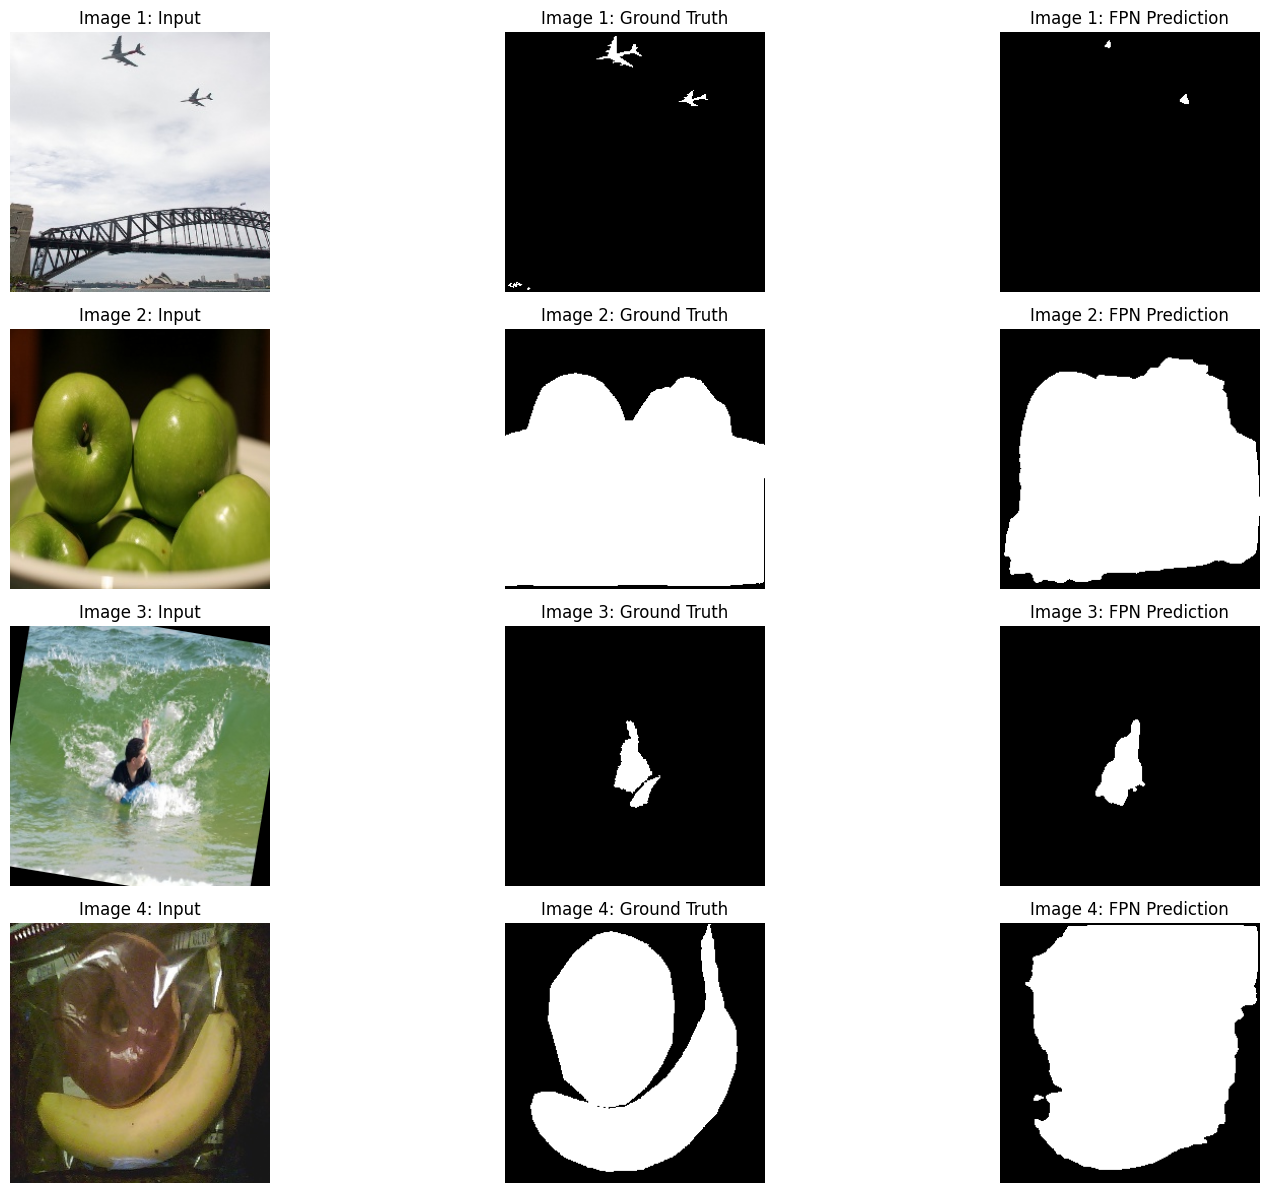

In [46]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_results(generator, model, num_images=5):
    # Grab a random batch from the generator
    # We take index 0, but you can change this to any valid index
    x_batch, y_batch = generator[0] 
    
    # Get predictions for the entire batch
    preds = model.predict(x_batch, verbose=0)
    # Apply 0.5 threshold to turn probabilities into a binary mask
    preds_binary = (preds > 0.5).astype(np.uint8)

    plt.figure(figsize=(15, 3 * num_images))
    
    for i in range(min(num_images, len(x_batch))):
        # 1. Original Image (Re-scale from [-1, 1] back to [0, 1] for display)
        plt.subplot(num_images, 3, i*3 + 1)
        display_img = (x_batch[i] + 1.0) / 2.0
        plt.imshow(display_img)
        plt.title(f"Image {i+1}: Input")
        plt.axis('off')

        # 2. Ground Truth Mask
        plt.subplot(num_images, 3, i*3 + 2)
        plt.imshow(y_batch[i].squeeze(), cmap='gray')
        plt.title(f"Image {i+1}: Ground Truth")
        plt.axis('off')

        # 3. Model Prediction
        plt.subplot(num_images, 3, i*3 + 3)
        plt.imshow(preds_binary[i].squeeze(), cmap='gray')
        plt.title(f"Image {i+1}: FPN Prediction")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_results(val_gen, model, num_images=5)

In [17]:
import os
import sys
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import segmentation_models as sm

# Force TensorFlow to use the Keras internal to TF
os.environ['SM_FRAMEWORK'] = 'tf.keras'

# Point to your source folder
sys.path.append(os.path.abspath('../src'))
from utils3 import VisionExtractFineTuneGenerator

# Load Data
train_gen = VisionExtractFineTuneGenerator('../data/processed/train', batch_size=8)
val_gen = VisionExtractFineTuneGenerator('../data/processed/val', batch_size=8)

In [18]:
def DilatedConvBlock(x, filters, dilation_rate):
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", dilation_rate=dilation_rate, use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    return tf.keras.layers.Activation("relu")(x)

def DeeplabV3Plus_VisionExtract(shape=(256, 256, 3)):
    base_model = tf.keras.applications.ResNet50(weights="imagenet", include_top=False, input_shape=shape)
    image_features = base_model.get_layer("conv4_block6_2_relu").output 
    
    # ASPP Block
    x = tf.keras.layers.AveragePooling2D(pool_size=(16, 16))(image_features)
    x = tf.keras.layers.Conv2D(256, 1, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    pool = tf.keras.layers.UpSampling2D((16, 16), interpolation="bilinear")(x)
    
    d1 = tf.keras.layers.Conv2D(256, 1, padding="same", use_bias=False)(image_features)
    d6 = DilatedConvBlock(image_features, 256, 6)
    d12 = DilatedConvBlock(image_features, 256, 12)
    
    x = tf.keras.layers.Concatenate()([pool, d1, d6, d12])
    x = tf.keras.layers.SpatialDropout2D(0.4)(x) 
    x = tf.keras.layers.Conv2D(256, 1, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    
    # Decoder
    x = tf.keras.layers.UpSampling2D((4, 4), interpolation="bilinear")(x)
    low_feat = base_model.get_layer("conv2_block3_2_relu").output
    low_feat = tf.keras.layers.Conv2D(48, 1, padding="same", use_bias=False)(low_feat)
    
    x = tf.keras.layers.Concatenate()([x, low_feat])
    x = tf.keras.layers.Conv2D(256, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.UpSampling2D((4, 4), interpolation="bilinear")(x)
    
    outputs = tf.keras.layers.Conv2D(1, 1, activation="sigmoid")(x)
    return tf.keras.models.Model(inputs=base_model.input, outputs=outputs)

model = DeeplabV3Plus_VisionExtract()

In [19]:
def bg_iou(y_true, y_pred):
    return sm.metrics.IOUScore(threshold=0.5, class_indexes=0)(y_true, y_pred)

def mean_iou(y_true, y_pred):
    sub = sm.metrics.IOUScore(threshold=0.5)(y_true, y_pred)
    bg = sm.metrics.IOUScore(threshold=0.5, class_indexes=0)(y_true, y_pred)
    return (sub + bg) / 2

def breakthrough_loss(y_true, y_pred):
    dice = sm.losses.DiceLoss()(y_true, y_pred)
    # 50x weight for planes
    bce = tf.nn.weighted_cross_entropy_with_logits(y_true, y_pred, pos_weight=50.0)
    return dice + tf.reduce_mean(bce)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=breakthrough_loss,
    metrics=[sm.metrics.IOUScore(threshold=0.5, name='subject_iou'), bg_iou, mean_iou, 'accuracy']
)

In [20]:
class VisionExtractVisualizer(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        # 1. Visualize First Sample
        x_batch, y_batch = val_gen[0]
        preds = self.model.predict(x_batch, verbose=0)
        idx = 0 
        
        # Normalize for Natural Color
        img_disp = (x_batch[idx] - x_batch[idx].min()) / (x_batch[idx].max() - x_batch[idx].min() + 1e-7)
        # Binary Mask for Sharpness (0.3 threshold)
        pred_binary = (preds[idx].squeeze() > 0.3).astype(np.uint8)

        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1); plt.imshow(img_disp); plt.title("Input Image"); plt.axis('off')
        plt.subplot(1, 3, 2); plt.imshow(y_batch[idx].squeeze(), cmap='gray', vmin=0, vmax=1); plt.title("Ground Truth"); plt.axis('off')
        plt.subplot(1, 3, 3); plt.imshow(pred_binary, cmap='gray', vmin=0, vmax=1); plt.title("DeepLabV3+ Prediction"); plt.axis('off')
        plt.show()
        
        # 2. Print Clean Decimals (No 'e' notation)
        print(f"\n--- Epoch {epoch+1} Results ---")
        print(f"Loss: {logs.get('loss'):.4f} | Subject IoU: {logs.get('subject_iou'):.4f}")
        print(f"BG IoU: {logs.get('bg_iou'):.4f} | Mean IoU: {logs.get('mean_iou'):.4f}")
        print("-" * 30)

# Final Training Start
callbacks = [VisionExtractVisualizer(), 
             tf.keras.callbacks.ModelCheckpoint('models/vision_best.keras', save_best_only=True, monitor='val_subject_iou', mode='max')]

print("🚀 Starting Final Training Loop...")
history = model.fit(train_gen, validation_data=val_gen, epochs=50, callbacks=callbacks)

🚀 Starting Final Training Loop...
Epoch 1/50
2334/3500 ━━━━━━━━━━━━━━━━━━━━ 1:13:25 4s/step - accuracy: 0.8955 - bg_iou: 0.2643 - loss: 2.0037 - mean_iou: 0.2643 - subject_iou: 0.2643

KeyboardInterrupt: 

In [ ]:
import os

image_folder = "../data/val2017"

total_images = len(os.listdir(image_folder))
print("Total Images:", total_images)


In [ ]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pycocotools.coco import COCO

# Paths
annotation_path = "../data/annotations/instances_val2017.json"
#train_dir = "../data/processed/train"
train_dir = "../data/val2017"
output_dir = "../data/processed/sample_binary_masks"

os.makedirs(output_dir, exist_ok=True)

# Load COCO
coco = COCO(annotation_path)

# Get image info once (optimization)
img_ids = coco.getImgIds()
img_infos = coco.loadImgs(img_ids)

# Get train images
train_images = os.listdir(train_dir)

# Select 5 random images
selected_images = random.sample(train_images, 5)

print("Selected Images:", selected_images)

for img_name in selected_images:

    # Find image info in JSON
    img_info = None
    for info in img_infos:
        if info["file_name"] == img_name:
            img_info = info
            break

    if img_info is None:
        print(f"Skipping {img_name}")
        continue

    img_id = img_info["id"]
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    # Create binary mask
    mask = np.zeros((img_info["height"], img_info["width"]), dtype=np.uint8)

    for ann in anns:
        mask = np.maximum(mask, coco.annToMask(ann))

    mask = mask * 255

    # Save mask
    mask_path = os.path.join(output_dir, img_name.replace(".jpg", ".png"))
    cv2.imwrite(mask_path, mask)

    # Load original image
    img_path = os.path.join(train_dir, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Apply mask
    masked_img = cv2.bitwise_and(img, img, mask=mask)

    # Display for THIS image
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Binary Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(masked_img)
    plt.title("Masked Output")
    plt.axis("off")

    plt.suptitle(img_name)
    plt.show()

print("Done!")


In [ ]:
import os
import cv2
import numpy as np
from pycocotools.coco import COCO
from tqdm.notebook import tqdm

# ================= PATH SETTINGS =================
BASE_PATH = "../data"   # Because notebook is inside notebooks/
ANNOTATION_FILE = os.path.join(BASE_PATH, "annotations/instances_val2017.json")
PROCESSED_FOLDER = os.path.join(BASE_PATH, "processed")
IMG_SIZE = 256
# =================================================

coco = COCO(ANNOTATION_FILE)


def create_binary_mask(img_id, height, width):
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    mask = np.zeros((height, width), dtype=np.uint8)

    for ann in anns:
        mask = np.maximum(mask, coco.annToMask(ann))

    return np.where(mask > 0, 255, 0).astype("uint8")


def preprocess_image(img, mask, split_type, img_name):

    save_base = os.path.join(PROCESSED_FOLDER, split_type)
    os.makedirs(save_base, exist_ok=True)

    # Resize
    resized_img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    resized_mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE),
                              interpolation=cv2.INTER_NEAREST)

    # Normalize
    normalized_img = resized_img / 255.0

    # Save processed outputs
    cv2.imwrite(os.path.join(save_base, img_name + "_resized.jpg"),
                cv2.cvtColor(resized_img, cv2.COLOR_RGB2BGR))

    cv2.imwrite(os.path.join(save_base, img_name + "_normalized.jpg"),
                (normalized_img * 255).astype(np.uint8))

    cv2.imwrite(os.path.join(save_base, img_name + "_mask.png"),
                resized_mask)

    # Subject isolation
    isolated = cv2.bitwise_and(resized_img, resized_img, mask=resized_mask)
    cv2.imwrite(os.path.join(save_base, img_name + "_isolated.jpg"),
                cv2.cvtColor(isolated, cv2.COLOR_RGB2BGR))

    # TRAIN AUGMENTATIONS ONLY
    if split_type == "train":

        h_flip = cv2.flip(resized_img, 1)
        cv2.imwrite(os.path.join(save_base, img_name + "_hflip.jpg"),
                    cv2.cvtColor(h_flip, cv2.COLOR_RGB2BGR))

        v_flip = cv2.flip(resized_img, 0)
        cv2.imwrite(os.path.join(save_base, img_name + "_vflip.jpg"),
                    cv2.cvtColor(v_flip, cv2.COLOR_RGB2BGR))

        center = (IMG_SIZE // 2, IMG_SIZE // 2)
        rot_matrix = cv2.getRotationMatrix2D(center, 30, 1.0)
        rotated = cv2.warpAffine(resized_img, rot_matrix,
                                 (IMG_SIZE, IMG_SIZE))
        cv2.imwrite(os.path.join(save_base, img_name + "_rot30.jpg"),
                    cv2.cvtColor(rotated, cv2.COLOR_RGB2BGR))

        bright = np.clip(normalized_img * 1.5, 0, 1)
        cv2.imwrite(os.path.join(save_base, img_name + "_bright.jpg"),
                    (bright * 255).astype(np.uint8))


def process_split(split_type):

    split_folder = os.path.join(PROCESSED_FOLDER, split_type)

    if not os.path.exists(split_folder):
        print(f"{split_type} folder not found!")
        return

    print(f"\nProcessing {split_type} images...")

    # ✅ Only process original images (avoid reprocessing)
    image_files = [
        f for f in os.listdir(split_folder)
        if f.endswith(".jpg") and
        "_resized" not in f and
        "_normalized" not in f and
        "_isolated" not in f and
        "_hflip" not in f and
        "_vflip" not in f and
        "_rot30" not in f and
        "_bright" not in f
    ]

    for file_name in tqdm(image_files):

        img_path = os.path.join(split_folder, file_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img_id = int(file_name.split(".")[0])

        img_info = coco.loadImgs(img_id)[0]
        height, width = img_info["height"], img_info["width"]

        mask = create_binary_mask(img_id, height, width)

        preprocess_image(img, mask, split_type, file_name.split(".")[0])


# ================= RUN =================

process_split("train")
process_split("val")
process_split("test")

print("\nPreprocessing Completed Successfully!")


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import random
import numpy as np

# ================= PATH SETUP =================

CURRENT_DIR = os.getcwd()
BASE_PATH = os.path.abspath(os.path.join(CURRENT_DIR, "..", "data"))

TRAIN_PATH = os.path.join(BASE_PATH, "processed", "train")
ORIGINAL_PATH = os.path.join(BASE_PATH, "val2017")  # original COCO images folder

print("Train Path:", TRAIN_PATH)
print("Original Path:", ORIGINAL_PATH)

# =============================================

files = os.listdir(TRAIN_PATH)

# Extract clean IDs
image_ids = list(set([f.split("_")[0].split(".")[0] for f in files]))

print("Total unique image IDs found:", len(image_ids))

sample_ids = random.sample(image_ids, 3)

for img_id in sample_ids:

    print(f"\nShowing outputs for Image ID: {img_id}")

    def safe_read(path, gray=False):
        if os.path.exists(path):
            return cv2.imread(path, 0 if gray else 1)
        else:
            return None

    # Load original image
    original = safe_read(os.path.join(ORIGINAL_PATH, f"{img_id}.jpg"))

    # Load processed images
    resized = safe_read(os.path.join(TRAIN_PATH, f"{img_id}_resized.jpg"))
    hflip = safe_read(os.path.join(TRAIN_PATH, f"{img_id}_hflip.jpg"))
    vflip = safe_read(os.path.join(TRAIN_PATH, f"{img_id}_vflip.jpg"))
    rot = safe_read(os.path.join(TRAIN_PATH, f"{img_id}_rot30.jpg"))
    mask = safe_read(os.path.join(TRAIN_PATH, f"{img_id}_mask.png"), gray=True)
    isolated = safe_read(os.path.join(TRAIN_PATH, f"{img_id}_isolated.jpg"))

    images_check = [original, resized, hflip, vflip, rot, mask, isolated]

    if any(img is None for img in images_check):
        print("Skipping incomplete image set.")
        continue

    # Convert BGR → RGB
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    resized = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    hflip = cv2.cvtColor(hflip, cv2.COLOR_BGR2RGB)
    vflip = cv2.cvtColor(vflip, cv2.COLOR_BGR2RGB)
    rot = cv2.cvtColor(rot, cv2.COLOR_BGR2RGB)
    isolated = cv2.cvtColor(isolated, cv2.COLOR_BGR2RGB)

    # Compute normalized & bright in memory
    normalized = resized / 255.0
    bright = np.clip(normalized * 1.5, 0, 1)

    # Plot 3x3 grid
    plt.figure(figsize=(18,14))

    titles = [
        "Original",
        "Resized",
        "Normalized",
        "H-Flip",
        "V-Flip",
        "Rotate 30°",
        "Brightened",
        "Binary Mask",
        "Subject Isolation"
    ]

    display_images = [
        original,
        resized,
        normalized,
        hflip,
        vflip,
        rot,
        bright,
        mask,
        isolated
    ]

    for i in range(9):
        plt.subplot(3,3,i+1)

        if i == 7:  # mask
            plt.imshow(display_images[i], cmap="gray")
        else:
            plt.imshow(display_images[i])

        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()
